# 1차 PE 정적 특징 기반 XGBoost 분류기

**범위:** 파일의 정상/악성 점수와 3단계 결과를 출력하고, Normal을 제외한
Suspicious·Malware의 **파일 경로 목록**까지 2차로 전달합니다. 2차 전처리·학습·예측은 구현하지 않습니다.

모델 학습 정답은 0=Normal, 1=Malware 두 개입니다. Suspicious는 세 번째 학습 클래스가 아니라
두 임계값 사이의 표시 구간입니다.

| 점수/상태 | 화면 결과 | 2차 전달 |
|---|---|---|
| score < LOW | Normal | 아니요 |
| LOW ≤ score < HIGH | Suspicious | 예 |
| score ≥ HIGH | Malware | 예 |
| 점수 산출 실패 | 별도 Error | 아니요 |

사용자 확정: Windows 로컬 중심/Colab 경로 변경 가능, 현재 80/10/10 유지, 파싱 실패는 별도 기록.
현재 실제 파일은 dataset/training_dataset 안에 있으므로 manifests의 training_path를 사용합니다.

## 실행 순서

1. 환경 설치·경로·실험 설정 → 공통 모듈 셀
2. 매니페스트 검증 → EDA → 파일 특징 미리 보기 → 전체 특징 캐시
3. PEMML-only / PEMML+BODMAS XGBoost 학습 → 학습 곡선
4. **Validation에서만** LOW/HIGH 실험 → 최종 임계값 확정
5. Test 최종 평가 → 출처별 비교 → 모델 패키지 저장/재로딩 검증
6. 새 파일 추론 → Normal/Error 제외 → 2차 연결용 목록

이 파일은 필요한 공통 모듈 소스를 모두 포함합니다. 각 writefile 셀이 이번 실행의 code/stage1에
코드를 생성하므로 이 ipynb와 데이터셋만 있어도 실행할 수 있습니다.
기존 노트북이나 데이터셋 원본을 수정하지 않습니다.


## 0. 참고한 설계 대화와 확정 사항

- [전체 프로그램/1차 구조](https://chatgpt.com/s/t_6aa7f3f4337081918f3591dc70ae30a7)
- [두 데이터셋의 활용과 출처 편향](https://chatgpt.com/s/t_6aa95d99d460819184601e0c524d4d60)
- [최종 데이터 구성: 양쪽 80/10/10](https://chatgpt.com/s/t_6aa9645f346881919c179a2189386e29)
- [입력 특징/전처리 규칙](https://chatgpt.com/s/t_6aa959bf6d988191a89b507d84829f73)
- [프로그램에 저장/로드할 자산](https://chatgpt.com/s/t_6aa952817c0c8191a924e691fcc8b5a9)

이전 제안의 PEMML 70/15/15·BODMAS 80/20 대신 사용자 확인을 받은 최종 80/10/10을 사용합니다.
원본 SHA-256 교차 중복 1개는 BODMAS에서 제외됐습니다.
PEMML은 label-stratified(random_state=42), BODMAS는 timestamp 순서로 만든 기존 split을 그대로 읽습니다.
imphash는 동일 계열을 보장하지 않으므로 분석만 하고 그룹 단위로 다시 나누지 않습니다.

XGBoost API: [학습/early stopping](https://xgboost.readthedocs.io/en/stable/python/python_api.html),
[모델 JSON 저장](https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html).
AP 정의: [Average Precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html).


## 1. 환경 준비

Python 3.12 커널을 권장합니다. 아래 설치 셀은 **처음 한 번만** 실행하고 이미 설치돼 있다면 건너뜁니다.
설치 후에는 커널을 재시작하고 2번부터 진행합니다. 설치 명령 앞의 주석을 해제하면 됩니다.
Windows에서는 실행 가능한 Python으로 Jupyter 커널을 선택하세요. 현재 프로젝트의 기존 venv는
원래 Python312 경로가 없어 실행에 실패하는 상태였으므로 새 환경을 선택해야 할 수 있습니다.
Colab에서는 데이터가 /content 또는 마운트한 Drive에 존재해야 하며 아래 DATASET_ROOT를 해당 위치로 바꿉니다.


In [79]:
# 선택 실행: 현재 노트북 커널에 설치합니다. 시스템 전체 환경을 자동 변경하지 않습니다.
# %pip install "numpy>=1.26,<3" "pandas>=2.2,<4" "scikit-learn>=1.5,<2" "xgboost>=3.0,<4" "pefile==2024.8.26" "matplotlib>=3.8,<4"
# 선택: 시각적 임계값 슬라이더를 쓸 때만 설치합니다.
# %pip install ipywidgets


## 2. 경로와 실험 설정 — 보통 이 셀부터 수정합니다


In [80]:
from pathlib import Path
from datetime import datetime, timezone
import os
import sys
import json
import hashlib
import importlib

PROJECT_ROOT = Path.cwd().resolve()
DATASET_ROOT = Path(r"D:\Dataset")
# Colab 예: DATASET_ROOT = Path("/content/drive/MyDrive/M_Project/dataset")
# Colab의 원격 Drive는 수십만 작은 파일 읽기가 느릴 수 있습니다.
# 이미 로컬 디스크에 준비된 데이터/특징 캐시를 쓰면 더 빠릅니다.
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts" / "stage1_xgboost"
RUN_MODE = "full"  # "smoke": 실행 흐름 확인용 소수 표본. 성능 결과로 사용하지 않습니다.
SMOKE_PER_GROUP = 8  # smoke일 때 split/source/label 각 그룹당 개수
SEED = 42
DEVICE = "cuda"  # GPU 환경은 "cuda". 자동 장치 변경 대신 실험 설정으로 남깁니다.
EXTRACTION_WORKERS = 2  # PE 읽기/파싱 병렬 수. 메모리를 확인하고 늘립니다.
CACHE_CHUNK_SIZE = 512

# 첫 실험용 값입니다. 최적값이나 성능 보장을 의미하지 않습니다.
# 뒤의 '임계값 실험' 셀에서 바꾸면 모델을 재학습하지 않고 즉시 비교할 수 있습니다.
LOW = 0.10
HIGH = 0.90
TARGET_SCREENING_RECALL = 0.99
TARGET_MALWARE_PRECISION = 0.99
ERROR_FORWARD = False  # 사용자가 확정: 파싱 실패는 별도 목록, 2차 전달 없음

if RUN_MODE not in {"full", "smoke"}:
    raise ValueError("RUN_MODE는 full 또는 smoke여야 합니다.")
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ") + "_" + RUN_MODE
RUN_DIR = ARTIFACT_ROOT / "runs" / RUN_ID
CODE_DIR = RUN_DIR / "code"
(CODE_DIR / "stage1").mkdir(parents=True, exist_ok=False)
REPORT_DIR = RUN_DIR / "reports"
REPORT_DIR.mkdir()
# 다음 writefile 셀은 실행 전용 폴더 안에 공유 모듈을 만듭니다.
os.chdir(CODE_DIR)
print("데이터:", DATASET_ROOT)
print("이번 실험:", RUN_DIR)


데이터: D:\Dataset
이번 실험: C:\stage1\artifacts\stage1_xgboost\runs\20260916T032236_860661Z_full


## 3. 학습·프로그램에서 공유할 특징 추출기

아래 코드를 그대로 배포 패키지에 저장합니다. 특징 이름·순서·계산법이 학습과 추론에서 일치합니다.
341개 수치 특징을 사용하며 원본 바이트 배열을 XGBoost에 그대로 넣지 않습니다.

- General 5, Header/Entry point 20, Section 통계 19, Import/Export 5,
  Data directory 32, Overlay 4, 정규화 Byte histogram 256.
- 없는 구조는 0, 읽을 수 없는 특징은 NaN. fatal error는 학습/예측에서 제외하고 기록.
- 경고가 있는 partial PE는 유효한 특징과 NaN으로 학습합니다. partial을 모두 제거하면
  패킹/RWX 구조가 많은 악성을 선택적으로 제외할 수 있습니다.
- BODMAS는 Machine/Subsystem **특징만** 제공 CSV로 보정합니다. PE 바이트는 수정하지 않습니다.
- original reference SHA와 실제 content SHA를 따로 기록합니다.
- 서명/체크섬 유효성, AV 탐지 수, source·hash·family·timestamp·imphash는 특징에서 제외합니다.
  Certificate table presence는 서명이 유효하다는 뜻이 아닙니다.
- 파일 크기/섹션 등 한도는 설정으로 남깁니다. 한도 초과도 Error로 집계되므로 평가에서 드러납니다.


In [81]:
%%writefile "{CODE_DIR.as_posix()}/stage1/__init__.py"
"""Stage1 shared code."""


Writing C:/stage1/artifacts/stage1_xgboost/runs/20260916T032236_860661Z_full/code/stage1/__init__.py


### 3-1. PE → 고정 길이 특징


In [82]:
%%writefile "{CODE_DIR.as_posix()}/stage1/feature_extractor.py"
"""학습/배포에서 함께 사용하는 읽기 전용 PE 정적 특징 추출기.

여기에는 XGBoost 예측이나 임계값 정책이 없다. 같은 버전의 이 파일과 설정을
학습/배포에 그대로 사용해야 특징 의미가 일치한다. 분석 대상 파일을 실행하거나
헤더를 복원하지 않는다. BODMAS의 원래 Machine/Subsystem은 특징 값만 대체한다.
"""
from __future__ import annotations

from dataclasses import asdict, dataclass
import hashlib
import math
from pathlib import Path
import re
import stat
import struct
import time
from typing import Any

import numpy as np
import pefile


FEATURE_VERSION = "pe_static_341_v2"
GENERAL_FEATURES = (
    "file_size", "file_entropy", "file_zero_ratio", "file_printable_ratio",
    "file_high_byte_ratio",
)
HEADER_FEATURES = (
    "header_machine", "header_section_count", "header_characteristics", "header_is_dll",
    "header_optional_magic", "header_entrypoint_rva", "header_size_code",
    "header_size_initialized_data", "header_size_uninitialized_data", "header_size_image",
    "header_size_headers", "header_subsystem", "header_dll_characteristics",
    "header_file_alignment", "header_section_alignment", "header_directory_count",
    "header_entrypoint_in_section", "header_entrypoint_section_executable",
    "header_entrypoint_section_entropy", "header_entrypoint_file_ratio",
)
SECTION_FEATURES = (
    "section_entropy_min", "section_entropy_mean", "section_entropy_max", "section_entropy_std",
    "section_raw_size_min", "section_raw_size_mean", "section_raw_size_max", "section_raw_size_sum",
    "section_virtual_size_min", "section_virtual_size_mean", "section_virtual_size_max",
    "section_virtual_size_sum", "section_readable_count", "section_writable_count",
    "section_executable_count", "section_write_exec_count", "section_rwx_count",
    "section_zero_raw_count", "section_raw_virtual_ratio_mean",
)
IMPORT_EXPORT_FEATURES = (
    "import_dll_count", "import_symbol_count", "import_ordinal_count",
    "export_symbol_count", "export_forwarder_count",
)
# PE/COFF에 정의된 인덱스 순서다. Security의 주소만 RVA가 아닌 파일 offset이다.
# 이름에 security가 있어도 '인증서 테이블 존재/선언 크기'일 뿐 서명 검증이 아니다.
DIRECTORY_NAMES = (
    "export", "import", "resource", "exception", "security", "reloc", "debug",
    "architecture", "globalptr", "tls", "load_config", "bound_import", "iat",
    "delay_import", "com_descriptor", "reserved",
)
DIRECTORY_FEATURES = tuple(
    f"directory_{name}_{measure}"
    for name in DIRECTORY_NAMES for measure in ("present", "size")
)
OVERLAY_FEATURES = ("overlay_present", "overlay_size", "overlay_ratio", "overlay_entropy")
BYTE_FEATURES = tuple(f"byte_hist_{value:03d}" for value in range(256))
FEATURE_NAMES = (
    GENERAL_FEATURES + HEADER_FEATURES + SECTION_FEATURES + IMPORT_EXPORT_FEATURES
    + DIRECTORY_FEATURES + OVERLAY_FEATURES + BYTE_FEATURES
)
assert len(FEATURE_NAMES) == len(set(FEATURE_NAMES)) == 341


@dataclass(frozen=True)
class ExtractorConfig:
    """설정도 모델과 저장한다. 한도를 넘긴 입력은 '정상'으로 치환하지 않는다.

    전체 파일은 chunk 단위로 한 번 읽어 SHA-256/히스토그램을 계산한다. 섹션과
    overlay는 추가로 읽되 누적 읽기 한도를 두어 중첩 섹션의 반복 읽기를 제한한다.
    pefile은 파일 경로를 받아 read-only mmap으로 헤더를 읽고 import/export만 푼다.
    이 제한은 크기/반복량 제한이며 엄격한 CPU timeout이나 격리 환경은 아니다.
    """

    max_file_bytes: int = 512 * 1024**2
    chunk_bytes: int = 1024**2
    max_region_read_bytes: int = 1024 * 1024**2
    max_sections: int = 128
    max_directory_bytes: int = 16 * 1024**2
    max_export_symbols: int = 8192

    def __post_init__(self):
        for name, value in asdict(self).items():
            if not isinstance(value, int) or isinstance(value, bool) or value <= 0:
                raise ValueError(f"{name} must be a positive integer")


DEFAULT_CONFIG = ExtractorConfig()


def extractor_config_dict(config: ExtractorConfig | None = None) -> dict:
    """JSON 저장 가능한 설정. 순서 목록/버전은 따로 저장해 재로딩 시 비교한다."""
    return asdict(config or DEFAULT_CONFIG)


def _entropy(counts: np.ndarray) -> float:
    total = int(counts.sum())
    if total == 0:
        return 0.0  # 실제 길이가 0인 영역: 내용이 없다는 관측값이다.
    probabilities = counts[counts > 0].astype(np.float64) / total
    return float(-np.sum(probabilities * np.log2(probabilities)))


def _counts(stream, start: int, size: int, chunk_bytes: int, digest=None) -> np.ndarray:
    """구간 전체를 읽지만 복사본은 chunk 크기로 제한한다. 짧은 읽기는 오류다."""
    stream.seek(start)
    counts = np.zeros(256, dtype=np.int64)
    remaining = size
    while remaining:
        block = stream.read(min(chunk_bytes, remaining))
        if not block:
            raise OSError("unexpected EOF while reading file")
        counts += np.bincount(np.frombuffer(block, dtype=np.uint8), minlength=256)
        if digest is not None:
            digest.update(block)
        remaining -= len(block)
    return counts


def _set_stats(features, prefix, values, *, entropy=False):
    values = np.asarray(values, dtype=np.float64)
    # 일부 섹션을 읽지 못했으면 전체 통계를 작게 왜곡하지 않고 NaN으로 유지한다.
    if len(values) == 0:
        if not entropy:
            features[f"{prefix}_sum"] = 0.0
        return
    if not np.isfinite(values).all():
        return
    for suffix, value in (("min", values.min()), ("mean", values.mean()), ("max", values.max())):
        features[f"{prefix}_{suffix}"] = float(value)
    features[f"{prefix}_{'std' if entropy else 'sum'}"] = float(values.std() if entropy else values.sum())


def _identity(file_stat):
    return (file_stat.st_dev, file_stat.st_ino, file_stat.st_size, file_stat.st_mtime_ns)


def _override_integer(value, name):
    # pandas가 정수 CSV 열을 332.0 형태로 전달해도 같은 값으로 받아들인다.
    number = float(value)
    if not math.isfinite(number) or number != int(number) or not 0 <= number <= 65535:
        raise ValueError(f"invalid BODMAS {name} metadata: {value!r}")
    return int(number)


def extract_pe_features(
    path,
    *,
    source: str | None = None,
    reference_sha256: str | None = None,
    machine_override=None,
    subsystem_override=None,
    config: ExtractorConfig | dict | None = None,
) -> dict[str, Any]:
    """파일 하나를 분석해 고정 341차원 float32 vector와 추적 metadata를 반환한다.

    source='bodmas': machine_override/subsystem_override가 반드시 있어야 한다.
    이것은 메타데이터 기반 특징 정정이며 파일/메모리의 PE 바이트 변경이 아니다.
    reference_sha256는 원본 식별자이고 content_sha256는 읽은 실제 파일 해시다.
    BODMAS는 비무장화로 이 둘이 다를 수 있다. PEMML/일반 입력에 reference가
    있으면 실제 해시와 대조한다. 새 파일 추론은 source/override 없이 호출한다.

    반환 키:
      vector: FEATURE_NAMES 순서의 np.float32 배열. fatal error이면 None.
      features: 같은 순서의 float 딕셔너리. fatal error이면 None.
      parse_status: 'ok' / 'partial'(일부 특징 결측 또는 parser 경고) / 'error'.
      error_reason: fatal 원인 문자열 또는 None; parse_warnings: 부분 오류 목록.
      path, size, source, reference_sha256, content_sha256, imphash,
      elapsed_seconds, feature_version: 진단/추적용이며 모델 입력에 넣지 않는다.

    읽을 수 없는 특징은 NaN, 실제로 없는 구조는 0을 사용한다. fatal error는
    점수를 만들 수 없으므로 호출자가 학습 제외/재검토/2차 전달 정책을 적용한다.
    이 함수는 어떠한 경우에도 정상/악성 판정이나 확률을 만들어 반환하지 않는다.
    """
    started = time.perf_counter()
    cfg = ExtractorConfig(**config) if isinstance(config, dict) else (config or DEFAULT_CONFIG)
    if not isinstance(cfg, ExtractorConfig):
        raise TypeError("config must be ExtractorConfig, dict, or None")
    file_path = Path(path).expanduser()
    source_name = str(source or "inference").strip().lower()
    reference = str(reference_sha256).strip().lower() if reference_sha256 is not None else None
    record = dict(
        path=str(file_path), size=None, source=source_name, reference_sha256=reference,
        content_sha256=None, imphash="", vector=None, features=None,
        parse_status="error", error_reason=None, parse_warnings=[],
        elapsed_seconds=0.0, feature_version=FEATURE_VERSION,
    )
    features = dict.fromkeys(FEATURE_NAMES, float("nan"))
    warnings = record["parse_warnings"]
    pe = None
    try:
        if reference is not None and not re.fullmatch(r"[0-9a-f]{64}", reference):
            raise ValueError("reference_sha256 must be 64 hexadecimal characters")
        if source_name == "bodmas":
            if machine_override is None or subsystem_override is None:
                raise ValueError("BODMAS requires original Machine and Subsystem metadata")
            machine = _override_integer(machine_override, "Machine")
            subsystem = _override_integer(subsystem_override, "Subsystem")
        elif machine_override is not None or subsystem_override is not None:
            raise ValueError("metadata header overrides are allowed only for source='bodmas'")

        before = file_path.stat()
        if not stat.S_ISREG(before.st_mode):
            raise ValueError("input must be a regular file")
        size = before.st_size
        record["size"] = size
        if size == 0 or size > cfg.max_file_bytes:
            raise ValueError(f"file size {size} outside range 1..{cfg.max_file_bytes}")

        with file_path.open("rb") as stream:
            # 해시와 byte histogram을 같은 한 번의 스트리밍 패스로 산출한다.
            digest = hashlib.sha256()
            counts = _counts(stream, 0, size, cfg.chunk_bytes, digest)
            record["content_sha256"] = digest.hexdigest()
            if reference is not None and source_name != "bodmas" and reference != record["content_sha256"]:
                raise ValueError("content_sha256 does not match reference_sha256")
            histogram = counts.astype(np.float64) / size
            features.update(zip(BYTE_FEATURES, histogram))
            features.update(file_size=size, file_entropy=_entropy(counts), file_zero_ratio=histogram[0],
                            file_printable_ratio=histogram[32:127].sum(), file_high_byte_ratio=histogram[128:].sum())

            # name=경로를 주면 pefile이 read-only mmap을 사용한다. data=전체 bytes
            # 방식처럼 큰 파일을 통째로 Python bytes에 복사하지 않는다.
            pe = pefile.PE(name=str(file_path), fast_load=True)
            if not hasattr(pe, "OPTIONAL_HEADER") or pe.OPTIONAL_HEADER.Magic not in (0x10B, 0x20B):
                raise ValueError("not a PE32 or PE32+ executable image")
            header, optional = pe.FILE_HEADER, pe.OPTIONAL_HEADER
            if header.NumberOfSections > cfg.max_sections:
                raise ValueError(f"section count exceeds {cfg.max_sections}")
            for name, obj, attribute in (
                ("machine", header, "Machine"), ("section_count", header, "NumberOfSections"),
                ("characteristics", header, "Characteristics"), ("optional_magic", optional, "Magic"),
                ("entrypoint_rva", optional, "AddressOfEntryPoint"), ("size_code", optional, "SizeOfCode"),
                ("size_initialized_data", optional, "SizeOfInitializedData"),
                ("size_uninitialized_data", optional, "SizeOfUninitializedData"),
                ("size_image", optional, "SizeOfImage"), ("size_headers", optional, "SizeOfHeaders"),
                ("subsystem", optional, "Subsystem"), ("dll_characteristics", optional, "DllCharacteristics"),
                ("file_alignment", optional, "FileAlignment"), ("section_alignment", optional, "SectionAlignment"),
                ("directory_count", optional, "NumberOfRvaAndSizes"),
            ):
                features[f"header_{name}"] = float(getattr(obj, attribute, float("nan")))
            features["header_is_dll"] = float(bool(header.Characteristics & 0x2000))
            if source_name == "bodmas":
                features["header_machine"], features["header_subsystem"] = float(machine), float(subsystem)
            # timestamp, 파일명, 경로, hash, raw checksum, 서명 유효성은 학습 특징에 없다.

            region_read_bytes = 0

            def region_entropy(offset, length):
                nonlocal region_read_bytes
                if offset < 0 or length < 0 or offset + length > size:
                    raise ValueError("declared raw range is outside the file")
                if region_read_bytes + length > cfg.max_region_read_bytes:
                    raise ValueError("section/overlay cumulative read budget exceeded")
                region_read_bytes += length
                return _entropy(_counts(stream, offset, length, cfg.chunk_bytes))

            sections = pe.sections
            section_complete = len(sections) == header.NumberOfSections
            if not section_complete:
                warnings.append("section: declared and parsed section counts differ")
            entropies, raw_sizes, virtual_sizes, characteristics, ratios = [], [], [], [], []
            for index, section in enumerate(sections):
                raw, virtual = int(section.SizeOfRawData), int(section.Misc_VirtualSize)
                raw_sizes.append(raw)
                virtual_sizes.append(virtual)
                characteristics.append(int(section.Characteristics))
                # 양쪽 길이가 0이면 비율도 0; virtual=0/raw>0은 정의되지 않은 값이다.
                ratios.append(raw / virtual if virtual else (0.0 if raw == 0 else float("nan")))
                try:
                    entropies.append(region_entropy(int(section.PointerToRawData), raw) if raw else 0.0)
                except (OSError, ValueError) as exc:
                    entropies.append(float("nan"))
                    warnings.append(f"section[{index}]: {exc}")
            if section_complete:
                _set_stats(features, "section_entropy", entropies, entropy=True)
                _set_stats(features, "section_raw_size", raw_sizes)
                _set_stats(features, "section_virtual_size", virtual_sizes)
                for name, mask in (("readable", 0x40000000), ("writable", 0x80000000),
                                   ("executable", 0x20000000), ("write_exec", 0xA0000000), ("rwx", 0xE0000000)):
                    features[f"section_{name}_count"] = float(sum(c & mask == mask for c in characteristics))
                features["section_zero_raw_count"] = float(sum(value == 0 for value in raw_sizes))
                if ratios and np.isfinite(ratios).all():
                    features["section_raw_virtual_ratio_mean"] = float(np.mean(ratios))

            entry = int(optional.AddressOfEntryPoint)
            matches = [i for i, s in enumerate(sections)
                       if s.VirtualAddress <= entry < s.VirtualAddress + max(s.Misc_VirtualSize, s.SizeOfRawData)]
            if section_complete:
                features["header_entrypoint_in_section"] = float(bool(matches))
            if len(matches) == 1:
                index, section = matches[0], sections[matches[0]]
                features["header_entrypoint_section_executable"] = float(bool(section.Characteristics & 0x20000000))
                features["header_entrypoint_section_entropy"] = entropies[index]
                displacement = entry - section.VirtualAddress
                offset = section.PointerToRawData + displacement
                if displacement < section.SizeOfRawData and 0 <= offset < size:
                    features["header_entrypoint_file_ratio"] = offset / size
            elif len(matches) > 1:
                warnings.append("entrypoint: overlapping sections make entrypoint section ambiguous")
            elif entry == 0:
                features["header_entrypoint_section_executable"] = 0.0
                features["header_entrypoint_section_entropy"] = 0.0
                features["header_entrypoint_file_ratio"] = 0.0
            elif entry < optional.SizeOfHeaders and entry < size:
                features["header_entrypoint_file_ratio"] = entry / size

            # 선언값이 0/0이면 부재(0), 손상/범위 오류는 unavailable(NaN)이다.
            # import/export의 내용만 파싱한다. 그 외 디렉터리는 위치/크기 구조를
            # 검사하지만 내부 의미/인증서 서명 유효성까지 검사했다는 뜻은 아니다.
            directories = getattr(optional, "DATA_DIRECTORY", [])
            states = {}
            for index, name in enumerate(DIRECTORY_NAMES):
                columns = (f"directory_{name}_present", f"directory_{name}_size")
                if index >= optional.NumberOfRvaAndSizes:
                    features.update(dict.fromkeys(columns, 0.0))
                    states[name] = "absent"
                    continue
                if index >= len(directories):
                    warnings.append(f"{name}: declared directory entry could not be read")
                    states[name] = "unavailable"
                    continue
                directory = directories[index]
                rva, length = int(directory.VirtualAddress), int(directory.Size)
                if rva == length == 0:
                    features.update(dict.fromkeys(columns, 0.0))
                    states[name] = "absent"
                    continue
                try:
                    # GlobalPtr는 PE 규격상 Size=0이다. 나머지는 위치/크기가 필요하다.
                    if rva == 0 or (length == 0 and name != "globalptr"):
                        raise ValueError("inconsistent directory address/size")
                    offset = rva if name == "security" else pe.get_offset_from_rva(rva)
                    if offset < 0 or offset >= size or offset + length > size:
                        raise ValueError("directory range is outside the file")
                    features[columns[0]], features[columns[1]] = 1.0, float(length)
                    states[name] = "present"
                except (pefile.PEFormatError, ValueError) as exc:
                    warnings.append(f"{name}: {exc}")
                    states[name] = "unavailable"

            for index, name, attribute, columns in (
                (1, "import", "DIRECTORY_ENTRY_IMPORT", IMPORT_EXPORT_FEATURES[:3]),
                (0, "export", "DIRECTORY_ENTRY_EXPORT", IMPORT_EXPORT_FEATURES[3:]),
            ):
                if states[name] == "absent":
                    features.update(dict.fromkeys(columns, 0.0))
                    continue
                if states[name] != "present":
                    continue
                try:
                    directory = directories[index]
                    if directory.Size > cfg.max_directory_bytes:
                        raise ValueError("directory parsing size budget exceeded")
                    if name == "export":
                        # Export 테이블 수가 비정상적으로 크면 pefile이 배열을 만들기
                        # 전에 중단한다. get_data도 40-byte 구조체만 요청한다.
                        data = pe.get_data(directory.VirtualAddress, 40)
                        if len(data) != 40 or directory.Size < 40:
                            raise ValueError("truncated export directory")
                        functions, names = struct.unpack_from("<II", data, 20)
                        if max(functions, names) > cfg.max_export_symbols:
                            raise ValueError("export symbol budget exceeded")
                    previous_warnings = len(pe.get_warnings())
                    pe.parse_data_directories(directories=[index])
                    new_warnings = pe.get_warnings()[previous_warnings:]
                    if new_warnings or not hasattr(pe, attribute):
                        # pefile은 예외 없이 일부만 읽고 경고를 내기도 한다. 이때
                        # 잘린 개수를 사실인 것처럼 제공하지 않고 해당 묶음을 NaN 유지.
                        raise ValueError("directory parser produced warnings or no parsed table")
                    if name == "import":
                        imports = pe.DIRECTORY_ENTRY_IMPORT
                        total = sum(len(dll.imports) for dll in imports)
                        if not imports or total == 0:
                            raise ValueError("declared import directory contains no readable imports")
                        ordinals = sum(bool(symbol.import_by_ordinal) for dll in imports for symbol in dll.imports)
                        values = (len(imports), total, ordinals)
                        # imphash는 유사 그룹 진단용 metadata이며 FEATURE_NAMES에 없다.
                        try:
                            record["imphash"] = pe.get_imphash() or ""
                        except Exception as exc:
                            warnings.append(f"imphash metadata: {type(exc).__name__}: {exc}")
                    else:
                        exports = pe.DIRECTORY_ENTRY_EXPORT.symbols
                        values = (len(exports), sum(bool(symbol.forwarder) for symbol in exports))
                    features.update(zip(columns, map(float, values)))
                except Exception as exc:
                    features[f"directory_{name}_present"] = float("nan")
                    features[f"directory_{name}_size"] = float("nan")
                    warnings.append(f"{name}: {type(exc).__name__}: {exc}")

            # overlay는 마지막 헤더/섹션 raw 영역 뒤의 데이터로 명시적으로 정의한다.
            # 설치 데이터와 인증서도 들어갈 수 있다. 서명 여부/악성 여부와 동일하지 않다.
            try:
                if not section_complete:
                    raise ValueError("incomplete section table prevents overlay calculation")
                image_end = max([int(optional.SizeOfHeaders)] +
                                [int(s.PointerToRawData) + int(s.SizeOfRawData) for s in sections if s.SizeOfRawData])
                if not 0 <= image_end <= size:
                    raise ValueError("declared image raw end is outside the file")
                overlay_size = size - image_end
                overlay_entropy = region_entropy(image_end, overlay_size) if overlay_size else 0.0
                features.update(overlay_present=float(overlay_size > 0), overlay_size=float(overlay_size),
                                overlay_ratio=overlay_size / size, overlay_entropy=overlay_entropy)
            except (OSError, ValueError) as exc:
                warnings.append(f"overlay: {exc}")

        # 파일이 분석 중 바뀌면 서로 다른 내용에서 얻은 해시/특징을 합치지 않는다.
        if _identity(before) != _identity(file_path.stat()):
            raise ValueError("file changed during feature extraction")
        warnings.extend(str(message) for message in pe.get_warnings())
        values = np.asarray([features[name] for name in FEATURE_NAMES], dtype=np.float64)
        invalid = np.isinf(values) | (np.abs(values) > np.finfo(np.float32).max)
        if invalid.any():
            warnings.append("nonfinite/float32 overflow values replaced by NaN")
            values[invalid] = np.nan
        vector = values.astype(np.float32)
        record["vector"] = vector
        record["features"] = dict(zip(FEATURE_NAMES, map(float, vector)))
        record["parse_status"] = "partial" if warnings else "ok"
    except Exception as exc:
        # 한 손상 파일 때문에 대규모 추출을 중단하지 않되 실패는 별도 기록한다.
        record["error_reason"] = f"{type(exc).__name__}: {exc}"
    finally:
        if pe is not None:
            pe.close()
        record["parse_warnings"] = list(dict.fromkeys(warnings))
        record["elapsed_seconds"] = time.perf_counter() - started
    return record


Writing C:/stage1/artifacts/stage1_xgboost/runs/20260916T032236_860661Z_full/code/stage1/feature_extractor.py


### 3-2. 기존 split 검증과 청크 특징 캐시

원본 메타데이터와 라벨/파일 ID/BODMAS 보정값을 대조합니다.
특징 캐시는 코드·버전·설정·행 순서가 달라지면 다른 폴더를 사용하며,
같은 실행을 다시 시작하면 완료된 청크를 재사용합니다.
원본 파일이 변경되면 크기/수정시간으로 기존 청크를 무효화합니다.


In [83]:
%%writefile "{CODE_DIR.as_posix()}/stage1/data_pipeline.py"
"""분할 매니페스트 검증과 재시작 가능한 PE 특징 캐시.

원본 PE/메타데이터에는 쓰지 않는다. 캐시에만 특징과 실패 기록을 저장한다.
CSV의 label/source/hash 등은 추적 정보이며 XGBoost 입력에 합치지 않는다.
"""

from __future__ import annotations

import hashlib
import json
import os
from concurrent.futures import ThreadPoolExecutor
from dataclasses import asdict, is_dataclass
from pathlib import Path

import numpy as np
import pandas as pd

from . import feature_extractor as fe


EXPECTED = {
    ("train", "PEMML", 0): 69450, ("train", "PEMML", 1): 91789,
    ("train", "BODMAS", 1): 45834,
    ("validation", "PEMML", 0): 8681, ("validation", "PEMML", 1): 11474,
    ("validation", "BODMAS", 1): 5729,
    ("test", "PEMML", 0): 8681, ("test", "PEMML", 1): 11474,
    ("test", "BODMAS", 1): 5729,
}


def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(4 * 1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def json_write(path: Path, payload) -> None:
    """중간에 중단돼도 완성되지 않은 JSON을 완료 파일로 착각하지 않게 교체한다."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_suffix(path.suffix + ".tmp")
    temp.write_text(json.dumps(payload, indent=2, ensure_ascii=False, allow_nan=False), encoding="utf-8")
    temp.replace(path)


def load_dataset(dataset_root: Path) -> tuple[pd.DataFrame, dict]:
    """사용자가 확정한 80/10/10을 재사용하고 원본 CSV와 대조한다."""
    root = Path(dataset_root).resolve()
    training_root = (root / "training_dataset").resolve()
    manifest_path = training_root / "manifests" / "all_samples.csv"
    manifest = pd.read_csv(manifest_path, dtype={
        "sample_id": str, "source": str, "training_path": str, "sha256": str,
        "family": "string", "imphash": "string", "timestamp": str,
    }, low_memory=False)
    required = {"sample_id", "source", "training_path", "sha256", "label",
                "family", "timestamp", "machine", "subsystem", "split"}
    if required - set(manifest):
        raise ValueError(f"매니페스트 필수 열 누락: {required - set(manifest)}")
    if len(manifest) != 258841:
        raise ValueError(f"확정 데이터셋은 258,841행이어야 합니다: {len(manifest):,}")
    for column in ("sample_id", "sha256", "training_path"):
        if manifest[column].isna().any() or manifest[column].duplicated().any():
            raise ValueError(f"{column} 결측/중복: 원본 매니페스트를 확인하세요.")
    counts = manifest.groupby(["split", "source", "label"]).size().to_dict()
    if counts != EXPECTED:
        raise ValueError(f"확정된 split/source/label별 개수와 다릅니다: {counts}")
    if not manifest.sha256.str.fullmatch(r"[0-9a-f]{64}").all():
        raise ValueError("SHA-256 식별자는 소문자 64자리 hex여야 합니다.")

    # training_path가 실제 학습 폴더의 파일을 가리킨다.
    # raw_path는 과거 원본 경로이므로 파일 접근에 쓰지 않는다.
    # Windows에서는 파일별 resolve가 반복적인 파일시스템 호출을 일으킨다.
    # 6개 디렉터리만 resolve하고, 파일은 정확히 split/class/name 3단계인지
    # 검증한 뒤 scandir에서 symlink/파일 종류를 확인해 안전성과 속도를 함께 유지한다.
    folders = {}
    for split in ("train", "validation", "test"):
        for class_name in ("benign", "malware"):
            folder = (training_root / split / class_name).resolve()
            if not folder.is_relative_to(training_root):
                raise ValueError(f"학습 폴더 밖으로 연결된 디렉터리: {folder}")
            folders[(split, class_name)] = folder
    resolved = []
    for row in manifest.itertuples():
        rel = Path(row.training_path)
        expected_class = "benign" if row.label == 0 else "malware"
        if rel.is_absolute() or len(rel.parts) != 3 or ".." in rel.parts:
            raise ValueError(f"학습 폴더 밖의 경로: {rel}")
        if rel.parts[:2] != (row.split, expected_class):
            raise ValueError(f"경로/라벨/split 불일치: {rel}")
        resolved.append(str(folders[(row.split, expected_class)] / rel.name))
    manifest["path"] = resolved
    # 대량 파일 검사도 디렉터리별 목록으로 수행해 파일당 stat 호출 비용을 줄인다.
    for (split, label), group in manifest.groupby(["split", "label"]):
        folder = folders[(split, "benign" if label == 0 else "malware")]
        with os.scandir(folder) as entries:
            actual = set()
            for entry in entries:
                if entry.is_symlink() or not entry.is_file(follow_symlinks=False):
                    raise ValueError(f"일반 파일이 아닌 데이터 항목: {entry.path}")
                actual.add(entry.name)
        expected = {Path(p).name for p in group.training_path}
        if actual != expected:
            raise ValueError(f"{folder}: 누락 {len(expected-actual)}, 추가 {len(actual-expected)}")

    csv_paths = {
        "pemml": root / "samples-augmented.csv",
        "bodmas": root / "bodmas_metadata.csv",
        "disarm": root / "bodmas_meta_disarm.csv",
    }
    # 프로젝트 루트에도 같은 이름의 BODMAS CSV가 있을 수 있다.
    # 서로 다른 사본이면 자동 선택하지 않고 명시적으로 중단한다.
    for key in ("bodmas", "disarm"):
        alternative = root.parent / csv_paths[key].name
        if not csv_paths[key].exists() and alternative.exists():
            csv_paths[key] = alternative
        elif alternative.exists() and sha256_file(alternative) != sha256_file(csv_paths[key]):
            raise ValueError(f"프로젝트/데이터 폴더 CSV 내용이 다릅니다: {alternative.name}")
    pemml = pd.read_csv(csv_paths["pemml"], dtype=str).set_index("sha256")
    bm = pd.read_csv(csv_paths["bodmas"], dtype=str).set_index("sha")
    disarm = pd.read_csv(csv_paths["disarm"], dtype=str).set_index("sha256")
    for source in (pemml, bm, disarm):
        if not source.index.is_unique:
            raise ValueError("원본 메타데이터에 중복 SHA가 있습니다.")
    p = manifest[manifest.source.eq("PEMML")]
    b = manifest[manifest.source.eq("BODMAS")]
    matched_p = pemml.loc[p.sha256]
    if not np.array_equal(matched_p["list"].map({"Whitelist": 0, "Blacklist": 1}), p.label):
        raise ValueError("PEMML 원본 CSV 라벨 불일치")
    expected_ids = "P_" + matched_p.id.str.zfill(6)
    if not np.array_equal(expected_ids, p.sample_id):
        raise ValueError("PEMML 파일 ID 불일치")
    matched_b, matched_d = bm.loc[b.sha256], disarm.loc[b.sha256]
    if not np.array_equal(matched_b.family.fillna(""), b.family.fillna("")):
        raise ValueError("BODMAS family 불일치")
    if not np.array_equal(pd.to_datetime(matched_b.timestamp, utc=True),
                          pd.to_datetime(b.timestamp, utc=True)):
        raise ValueError("BODMAS timestamp 불일치")
    for col, original in (("machine", "FILE_HEADER.Machine"),
                          ("subsystem", "OPTIONAL_HEADER.Subsystem")):
        if not np.array_equal(pd.to_numeric(matched_d[original]), b[col]):
            raise ValueError(f"BODMAS {col} 보정값 불일치")
    original_malware = bm[bm.family.notna()]
    overlap = sorted(set(pemml.index) & set(original_malware.index))
    if len(overlap) != 1 or set(b.sha256) != set(original_malware.index) - set(overlap):
        raise ValueError("PEMML/BODMAS 중복 제거 내역이 최종 계획과 다릅니다.")
    if pemml.loc[overlap, "list"].ne("Blacklist").any():
        raise ValueError("출처 간 중복 SHA의 라벨 충돌")

    bounds = {}
    for split in ("train", "validation", "test"):
        time = pd.to_datetime(b.loc[b.split.eq(split), "timestamp"], utc=True)
        bounds[split] = [time.min().isoformat(), time.max().isoformat()]
    if not (bounds["train"][1] <= bounds["validation"][0] <= bounds["validation"][1] <= bounds["test"][0]):
        raise ValueError("BODMAS 시간 분할 순서 위반")
    # imphash는 같은 family라는 뜻이 아니므로 분석만 하고 다시 split하지 않는다.
    present = p[p.imphash.notna() & p.imphash.ne("")]
    cross = present.groupby("imphash").split.nunique().gt(1)
    audit = {
        "manifest_sha256": sha256_file(manifest_path),
        "source_csv_sha256": {key: sha256_file(path) for key, path in csv_paths.items()},
        "rows": len(manifest), "bodmas_time_bounds": bounds,
        "cross_source_duplicate_excluded": overlap,
        "imphash_groups_spanning_splits": int(cross.sum()),
        "imphash_samples_spanning_splits": int(present.imphash.isin(cross[cross].index).sum()),
        "path_base": str(training_root),
    }
    manifest.index.name = "row_id"
    return manifest, audit


def config_dict(config) -> dict:
    return asdict(config) if is_dataclass(config) else dict(config or {})


def cache_features(manifest: pd.DataFrame, cache_root: Path, config,
                   *, workers=2, chunk_size=512) -> tuple[np.ndarray, pd.DataFrame, Path]:
    """청크 단위 저장: 재실행 시 완료 청크만 읽고 미완료 청크를 다시 처리한다.

    캐시 키에는 행 순서·추출 코드·설정·pefile 버전이 들어간다.
    기존 청크의 파일 크기/수정시간도 비교한다. 원본을 덮어쓰지 않는 데이터셋을 전제로 한다.
    """
    if len(manifest) == 0 or chunk_size < 1 or workers < 1:
        raise ValueError("비어 있지 않은 데이터와 양의 workers/chunk_size가 필요합니다.")
    serialized = manifest[["sample_id", "source", "sha256", "path", "machine", "subsystem"]].to_csv(index=False)
    key_config = {
        "extractor_source_sha256": sha256_file(Path(fe.__file__)),
        "config": config_dict(config), "features": list(fe.FEATURE_NAMES),
        "pefile_version": fe.pefile.__version__, "chunk_size": chunk_size,
    }
    digest = hashlib.sha256((serialized + json.dumps(key_config, sort_keys=True)).encode()).hexdigest()
    folder = Path(cache_root) / digest[:24]
    folder.mkdir(parents=True, exist_ok=True)
    json_write(folder / "cache_config.json", {**key_config, "manifest_fingerprint": digest})

    def extract(row):
        return fe.extract_pe_features(
            row.path, source=row.source, reference_sha256=row.sha256,
            machine_override=row.machine if row.source == "BODMAS" else None,
            subsystem_override=row.subsystem if row.source == "BODMAS" else None,
            config=config,
        )

    matrices, records = [], []
    with ThreadPoolExecutor(max_workers=workers) as executor:
        for start in range(0, len(manifest), chunk_size):
            chunk = manifest.iloc[start:start+chunk_size]
            path = folder / f"chunk_{start:07d}.npz"
            # 파일이 검증 이후 격리/삭제되거나 접근 불가가 되어도 배치를 중단하지 않는다.
            # stat 실패 청크는 캐시를 재사용하지 않고 추출기에 넘겨 개별 Error로 기록한다.
            stats = []
            for input_path in chunk.path:
                try:
                    stats.append(Path(input_path).stat())
                except OSError:
                    stats.append(None)
            sizes = np.array([s.st_size if s else -1 for s in stats], dtype=np.int64)
            mtimes = np.array([s.st_mtime_ns if s else -1 for s in stats], dtype=np.int64)
            cached = None
            if path.exists() and all(s is not None for s in stats):
                # allow_pickle=False: 데이터 캐시를 읽으면서 코드를 역직렬화하지 않는다.
                with np.load(path, allow_pickle=False) as z:
                    if (np.array_equal(z["sizes"], sizes) and np.array_equal(z["mtimes"], mtimes)
                            and np.array_equal(z["sample_id"], chunk.sample_id.to_numpy(str))):
                        cached = {key: z[key].copy() for key in z.files}
            if cached is None:
                outputs = list(executor.map(extract, chunk.itertuples()))
                cached = {
                    # fatal 오류도 행을 유지해야 원래 테스트 분모가 사라지지 않는다.
                    # 이 NaN 행은 아래 학습 코드가 제외하고 평가에서는 Error로 센다.
                    "X": np.stack([r["vector"] if r["vector"] is not None else
                                   np.full(len(fe.FEATURE_NAMES), np.nan, dtype=np.float32)
                                   for r in outputs]).astype(np.float32),
                    "sample_id": chunk.sample_id.to_numpy(str), "sizes": sizes, "mtimes": mtimes,
                    "parse_status": np.array([r["parse_status"] for r in outputs], dtype=str),
                    "error_reason": np.array([r["error_reason"] or "" for r in outputs], dtype=str),
                    "parse_warnings": np.array([json.dumps(r["parse_warnings"], ensure_ascii=False) for r in outputs], dtype=str),
                    "content_sha256": np.array([r["content_sha256"] or "" for r in outputs], dtype=str),
                    "elapsed_seconds": np.array([r["elapsed_seconds"] for r in outputs]),
                }
                temp = path.with_suffix(".tmp")
                with temp.open("wb") as stream:
                    np.savez_compressed(stream, **cached)
                temp.replace(path)
            matrices.append(cached["X"])
            records.append(pd.DataFrame({k: cached[k] for k in (
                "sample_id", "parse_status", "error_reason", "parse_warnings",
                "content_sha256", "elapsed_seconds")}))
            print(f"특징 캐시: {min(start+chunk_size, len(manifest)):,}/{len(manifest):,}", flush=True)
    X = np.concatenate(matrices)
    extracted = pd.concat(records, ignore_index=True)
    if not np.array_equal(extracted.sample_id, manifest.sample_id):
        raise RuntimeError("특징/메타데이터 행 정렬 불일치")
    metadata = manifest.reset_index(drop=True).copy()
    for name in extracted.columns.difference(["sample_id"]):
        metadata[name] = extracted[name].to_numpy()
    metadata.index.name = "row_id"
    # 서로 다른 원본 식별자가 실제 동일한 바이트로 나타나는 경우도 누수 검사한다.
    valid_hash = metadata.content_sha256.ne("")
    collisions = metadata[valid_hash].groupby("content_sha256").agg(
        splits=("split", "nunique"), labels=("label", "nunique"))
    if (collisions.splits.gt(1) | collisions.labels.gt(1)).any():
        collisions[collisions.splits.gt(1) | collisions.labels.gt(1)].to_csv(folder / "content_hash_conflicts.csv")
        raise ValueError("실제 바이트 해시의 split/label 충돌: content_hash_conflicts.csv를 확인하세요.")
    metadata.to_csv(folder / "metadata.csv", index=False)
    metadata[metadata.parse_status.eq("error")].to_csv(folder / "extraction_errors.csv", index=False)
    return X, metadata, folder


Writing C:/stage1/artifacts/stage1_xgboost/runs/20260916T032236_860661Z_full/code/stage1/data_pipeline.py


### 3-3. 3단계 라우팅·지표·임계값 비교·그래프

**주 지표:** 전체 악성 중 2차로 보낸 비율(screening recall), 보낼 기회를 놓친 비율(screening FNR).
Error 악성은 2차에 보내지 않으므로 전체 FNR에도 포함합니다.
모델 점수가 나온 파일만의 recall/FNR도 별도로 보여 파싱 문제와 모델 문제를 구분합니다.

**비용 지표:** 정상 중 2차에 전달한 비율(FPR/benign forward rate), 전체 전달 비율, 정상 필터율.
**보조 지표:** Average Precision(AP), ROC-AUC, logloss, 이진 F1, high 경계의 Malware precision.
AP는 PR 곡선의 사다리꼴 면적과 다른 정의라 명확히 구분합니다.
BODMAS는 악성만 있으므로 정상 오탐/precision/AUC를 검증할 수 없는 값은 NaN으로 표시합니다.
2×3 혼동행렬은 정답 2종과 표시 3단계를 비교하며 Error는 별도 막대로 표시합니다.


In [84]:
%%writefile "{CODE_DIR.as_posix()}/stage1/evaluation.py"
"""1차 분류기의 점수, 3단계 판정, 2차 전달량을 함께 평가하는 함수.

모델은 정상/악성 이진 분류를 학습하고, 두 임계값이 표시 결과를 3단계로
나눕니다. Suspicious는 세 번째 학습 정답이 아닙니다. 실제 정답은 label=0/1
뿐이므로 혼동행렬도 실제 2개 클래스 × 표시 3개 단계로 만듭니다.

NaN은 추출/예측 오류를 나타내며 악성 확률이 아닙니다. 오류를 0이나 1로
채워 모델 성능을 부풀리지 않습니다. 오류 정책은 error_forward로 반드시
명시합니다. 이 프로젝트에서는 False를 사용하여 오류를 따로 보관합니다.
"""

from __future__ import annotations

from typing import Any, Iterable

import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)


BAND_ORDER = ("Normal", "Suspicious", "Malware")


def _validate_thresholds(low: float, high: float) -> tuple[float, float]:
    """두 경계가 뒤집히거나 의심 구간이 사라지는 설정을 조기에 잡습니다."""
    low, high = float(low), float(high)
    if not (np.isfinite(low) and np.isfinite(high) and 0 <= low < high <= 1):
        raise ValueError("임계값은 0 <= low < high <= 1이어야 합니다.")
    return low, high


def _validate_scores(scores: Iterable[float]) -> np.ndarray:
    values = np.asarray(scores, dtype=float)
    if values.ndim != 1:
        raise ValueError("scores는 행 순서에 맞춘 1차원 악성 확률 배열이어야 합니다.")
    # NaN만 오류 표기로 허용합니다. inf/범위 밖 숫자는 파이프라인 버그일 수
    # 있으므로 조용히 오류로 바꾸지 않고 원인을 고치도록 예외를 발생시킵니다.
    if np.isinf(values).any() or ((values < 0) | (values > 1)).any():
        raise ValueError("점수는 [0, 1] 또는 오류를 뜻하는 NaN이어야 합니다.")
    return values


def _validate_inputs(metadata: pd.DataFrame, scores: Iterable[float]) -> tuple[np.ndarray, np.ndarray]:
    if "label" not in metadata:
        raise ValueError("metadata에 label 열(정상=0, 악성=1)이 필요합니다.")
    values = _validate_scores(scores)
    if len(metadata) != len(values):
        raise ValueError("metadata와 scores의 행 수가 다릅니다. 같은 행 순서를 유지하세요.")
    if metadata["label"].isna().any() or not metadata["label"].isin([0, 1]).all():
        raise ValueError("평가 정답 label은 결측 없는 0/1이어야 합니다.")
    return metadata["label"].to_numpy(dtype=np.int8), values


def _validate_error_policy(error_forward: bool) -> None:
    if not isinstance(error_forward, (bool, np.bool_)):
        raise ValueError("error_forward는 명시적인 bool이어야 합니다.")


def _ratio(numerator: Any, denominator: Any) -> np.ndarray:
    """분모가 없는 지표는 0/100%를 만들지 않고 NaN으로 둡니다."""
    numerator, denominator = np.broadcast_arrays(
        np.asarray(numerator, dtype=float), np.asarray(denominator, dtype=float)
    )
    result = np.full(numerator.shape, np.nan, dtype=float)
    np.divide(numerator, denominator, out=result, where=denominator != 0)
    return result


def route_scores(
    scores: Iterable[float], low: float, high: float, *, error_forward: bool
) -> pd.DataFrame:
    """점수를 3단계로 표시하고 2차 전달 여부를 결정합니다(2차 모델 호출 없음).

    경계와 같은 값은 위쪽 단계에 포함합니다. 즉 low는 Suspicious,
    high는 Malware입니다. 정상 외 두 단계 모두 2차 전달 후보입니다.
    Error는 별도 상태이므로 3단계 모델 판정으로 계산하지 않습니다.
    """
    low, high = _validate_thresholds(low, high)
    _validate_error_policy(error_forward)
    values = _validate_scores(scores)
    scored = np.isfinite(values)
    bands = np.full(len(values), "Error", dtype=object)
    bands[scored & (values < low)] = "Normal"
    bands[scored & (values >= low) & (values < high)] = "Suspicious"
    bands[scored & (values >= high)] = "Malware"
    return pd.DataFrame(
        {
            "malware_score": values,
            "stage1_result": bands,
            "needs_stage2": (scored & (values >= low)) | (~scored & error_forward),
            "score_valid": scored,
        }
    )


def threshold_curve(
    metadata: pd.DataFrame,
    scores: Iterable[float],
    thresholds: Iterable[float],
    *,
    error_forward: bool,
) -> pd.DataFrame:
    """한 번 정렬한 누적 개수로 여러 threshold를 빠르게 비교합니다.

    매 threshold마다 전체 데이터를 다시 예측/순회하지 않습니다.
    시간 복잡도는 O(N log N + G log N)입니다(N=파일 수, G=경계 후보 수).
    오류를 별도 처리하는 정책에서는 오류 악성을 전체 recall의 분모에
    포함하고 분자에는 넣지 않아, 추출 실패로 누락된 악성을 숨기지 않습니다.

    *_scored는 정상적으로 점수가 나온 파일에 한정한 모델 지표입니다.
    접미사가 없는 screening/forward 지표의 분모는 오류를 포함한 전체입니다.
    malware_*는 score>=threshold 표시 성능이며 오류를 Malware로 세지 않습니다.
    """
    labels, values = _validate_inputs(metadata, scores)
    _validate_error_policy(error_forward)
    grid = np.asarray(list(thresholds), dtype=float)
    if grid.ndim != 1 or not np.isfinite(grid).all() or ((grid < 0) | (grid > 1)).any():
        raise ValueError("thresholds는 [0, 1] 내 유한한 1차원 값이어야 합니다.")

    valid = np.isfinite(values)
    order = np.argsort(values[valid], kind="stable")
    sorted_scores = values[valid][order]
    sorted_labels = labels[valid][order]
    # prefix[k]는 정렬된 앞쪽 k개 중 악성의 수입니다. side='left' 덕분에
    # score==threshold인 동점 파일은 모두 전달/악성 후보에 포함됩니다.
    prefix_positive = np.concatenate(([0], np.cumsum(sorted_labels, dtype=np.int64)))
    cut = np.searchsorted(sorted_scores, grid, side="left")
    positive_scored = int(sorted_labels.sum())
    negative_scored = len(sorted_labels) - positive_scored
    tp = positive_scored - prefix_positive[cut]
    n_predicted = len(sorted_labels) - cut
    fp = n_predicted - tp
    fn = positive_scored - tp
    tn = negative_scored - fp
    positive_total = int(labels.sum())
    negative_total = len(labels) - positive_total
    positive_errors = positive_total - positive_scored
    negative_errors = negative_total - negative_scored
    forwarded_positive = tp + (positive_errors if error_forward else 0)
    forwarded_negative = fp + (negative_errors if error_forward else 0)

    # BODMAS처럼 악성만 있는 집합에서는 precision=1이나 AP=1을 출력해도
    # 정상 오탐을 검증한 적이 없습니다. precision/F1은 양 클래스가 있는
    # scored 집합에서만 제공하고, 악성 recall 자체는 계속 제공합니다.
    both_classes = positive_scored > 0 and negative_scored > 0
    precision = _ratio(tp, n_predicted) if both_classes else np.full(len(grid), np.nan)
    f1 = _ratio(2 * tp, 2 * tp + fp + fn) if both_classes else np.full(len(grid), np.nan)
    return pd.DataFrame(
        {
            "threshold": grid,
            "n_scored_positive_predictions": n_predicted,
            "n_true_positive_scored": tp,
            "n_false_positive_scored": fp,
            "n_false_negative_scored": fn,
            "n_true_negative_scored": tn,
            "n_forward": forwarded_positive + forwarded_negative,
            "screening_recall": _ratio(forwarded_positive, positive_total),
            "screening_fnr": _ratio(positive_total - forwarded_positive, positive_total),
            "benign_forward_rate": _ratio(forwarded_negative, negative_total),
            "benign_filter_rate": _ratio(tn, negative_total),
            "overall_forward_rate": _ratio(forwarded_positive + forwarded_negative, len(labels)),
            "screening_recall_scored": _ratio(tp, positive_scored),
            "screening_fnr_scored": _ratio(fn, positive_scored),
            "benign_forward_rate_scored": _ratio(fp, negative_scored),
            "benign_filter_rate_scored": _ratio(tn, negative_scored),
            "malware_precision": precision,
            "malware_recall": _ratio(tp, positive_total),
            "malware_recall_scored": _ratio(tp, positive_scored),
            "malware_fpr": _ratio(fp, negative_total),
            "malware_fpr_scored": _ratio(fp, negative_scored),
            "binary_f1_scored": f1,
        }
    )


def evaluate_scores(
    metadata: pd.DataFrame,
    scores: Iterable[float],
    low: float,
    high: float,
    *,
    error_forward: bool,
) -> pd.DataFrame:
    """전체 및 각 출처별 평가표를 반환합니다. 파일 저장은 호출자가 결정합니다.

    주 지표는 screening_recall/FNR입니다. 1차에서 놓친 악성은 2차가
    검사할 기회가 없기 때문입니다. benign_forward_rate와 전달량은 그
    recall을 얻기 위해 정상 파일을 얼마나 2차로 보내는지 보여줍니다.
    accuracy는 다수 클래스 비율에 가려질 수 있어 대표 지표로 쓰지 않습니다.
    """
    low, high = _validate_thresholds(low, high)
    labels, values = _validate_inputs(metadata, scores)
    _validate_error_policy(error_forward)
    if "source" not in metadata or metadata["source"].isna().any():
        raise ValueError("출처별 평가를 위해 결측 없는 source 열이 필요합니다.")
    source_values = metadata["source"].astype(str).to_numpy()
    masks = [("overall", np.ones(len(metadata), dtype=bool))]
    masks += [(source, source_values == source) for source in pd.unique(source_values)]
    rows = []
    for source, mask in masks:
        group = metadata.loc[mask]
        y, p = labels[mask], values[mask]
        valid = np.isfinite(p)
        y_scored, p_scored = y[valid], p[valid]
        both_classes = len(np.unique(y_scored)) == 2
        curve = threshold_curve(group, p, [low, high], error_forward=error_forward)
        lo, hi = curve.iloc[0], curve.iloc[1]
        routing = route_scores(p, low, high, error_forward=error_forward)
        row = {
            "source": source,
            "n_total": len(y),
            "n_benign": int((y == 0).sum()),
            "n_malware": int((y == 1).sum()),
            "n_scored": int(valid.sum()),
            "n_errors": int((~valid).sum()),
            "n_error_benign": int(((~valid) & (y == 0)).sum()),
            "n_error_malware": int(((~valid) & (y == 1)).sum()),
            "score_coverage": float(_ratio(valid.sum(), len(y))),
            "score_coverage_benign": float(_ratio((valid & (y == 0)).sum(), (y == 0).sum())),
            "score_coverage_malware": float(_ratio((valid & (y == 1)).sum(), (y == 1).sum())),
            "low": low,
            "high": high,
            "error_forward": bool(error_forward),
            "n_normal": int((routing.stage1_result == "Normal").sum()),
            "n_suspicious": int((routing.stage1_result == "Suspicious").sum()),
            "n_malware_band": int((routing.stage1_result == "Malware").sum()),
            "n_forward": int(lo.n_forward),
        }
        for name in (
            "screening_recall", "screening_fnr", "benign_forward_rate", "benign_filter_rate",
            "overall_forward_rate", "screening_recall_scored", "screening_fnr_scored",
            "benign_forward_rate_scored", "benign_filter_rate_scored",
        ):
            row[name] = float(lo[name])
        for name in (
            "malware_precision", "malware_recall", "malware_recall_scored",
            "malware_fpr", "malware_fpr_scored",
        ):
            row[name] = float(hi[name])
        row["binary_f1_scored_at_low"] = float(lo.binary_f1_scored)
        row["binary_f1_scored_at_high"] = float(hi.binary_f1_scored)
        # AP는 Average Precision입니다. PR 곡선을 사다리꼴로 적분한 면적과
        # 계산 방식이 다르므로 'PR-AUC'로 뭉뚱그려 이름 붙이지 않습니다.
        row["average_precision_scored"] = float(average_precision_score(y_scored, p_scored)) if both_classes else np.nan
        row["roc_auc_scored"] = float(roc_auc_score(y_scored, p_scored)) if both_classes else np.nan
        # Log loss는 단일 클래스에서도 정의됩니다. labels를 명시하여
        # sklearn이 관측되지 않은 클래스를 누락해 예외를 내지 않게 합니다.
        row["log_loss_scored"] = float(log_loss(y_scored, p_scored, labels=[0, 1])) if len(y_scored) else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index("source")


def recommend_thresholds(
    metadata: pd.DataFrame,
    scores: Iterable[float],
    *,
    error_forward: bool,
    target_screening_recall: float = 0.99,
    target_malware_precision: float = 0.99,
    thresholds: Iterable[float] | None = None,
) -> dict[str, Any]:
    """validation에서만 임계값 후보를 제안합니다. 설정을 자동 변경하지 않습니다.

    목표를 만족하는 쌍 중 low를 크게 하여 2차 전달을 줄이고, 그 low보다
    큰 high 중 가장 작은 값을 골라 Malware 표시 recall을 확보합니다.
    그리드 밖 해답이나 실제 배포 성능을 보장하지 않습니다. 오류/점수 때문에
    목표가 불가능하면 low/high=None과 이유를 반환하여 수동 판단을 요청합니다.
    """
    _validate_inputs(metadata, scores)
    _validate_error_policy(error_forward)
    # test에서 임계값을 고르면 최종 평가를 이미 본 데이터에 맞추게 됩니다.
    # 파일 이름 추측 대신 매니페스트의 split 열로 validation임을 확인합니다.
    if "split" not in metadata or metadata.empty or not metadata["split"].eq("validation").all():
        raise ValueError("임계값 추천에는 split='validation'인 매니페스트만 사용할 수 있습니다.")
    if not (0 < target_screening_recall <= 1 and 0 < target_malware_precision <= 1):
        raise ValueError("목표 recall/precision은 0보다 크고 1 이하여야 합니다.")
    grid = np.linspace(0, 1, 1001) if thresholds is None else list(thresholds)
    curve = threshold_curve(metadata, scores, grid, error_forward=error_forward)
    curve = curve.sort_values("threshold").drop_duplicates("threshold").reset_index(drop=True)
    result = {
        "feasible": False,
        "low": None,
        "high": None,
        "reason": "",
        "selection_split": "validation",
        "target_screening_recall": float(target_screening_recall),
        "target_malware_precision": float(target_malware_precision),
        "error_forward": bool(error_forward),
        "candidate_count": len(curve),
    }
    low_candidates = curve.loc[curve.screening_recall >= target_screening_recall]
    high_candidates = curve.loc[curve.malware_precision >= target_malware_precision]
    if low_candidates.empty:
        maximum = curve.screening_recall.max()
        result["reason"] = (
            "validation에서 목표 screening recall을 만족하는 low가 없습니다. "
            f"그리드 내 최대 전체 recall={maximum!r}; 추출/예측 오류도 분모에 포함합니다."
        )
        return result
    if high_candidates.empty:
        result["reason"] = (
            "validation에서 목표 Malware precision을 만족하는 high가 없습니다. "
            "양 클래스의 유효 점수와 실제 Malware 판정 표본이 필요합니다."
        )
        return result
    # 가능한 최대 high보다 작은 low만 고르면 쌍 탐색에 이중 루프가 필요 없습니다.
    low_candidates = low_candidates.loc[low_candidates.threshold < high_candidates.threshold.max()]
    if low_candidates.empty:
        result["reason"] = "두 목표를 만족하면서 low < high인 임계값 쌍이 그리드에 없습니다."
        return result
    lo = low_candidates.iloc[-1]
    hi = high_candidates.loc[high_candidates.threshold > lo.threshold].iloc[0]
    result.update(
        feasible=True,
        low=float(lo.threshold),
        high=float(hi.threshold),
        reason="validation 그리드의 경험적 목표를 만족하는 제안입니다. 설정에 수동 적용하세요.",
        validation_screening_recall=float(lo.screening_recall),
        validation_benign_forward_rate=float(lo.benign_forward_rate),
        validation_overall_forward_rate=float(lo.overall_forward_rate),
        validation_malware_precision=float(hi.malware_precision),
        validation_malware_band_count=int(hi.n_scored_positive_predictions),
    )
    return result


def plot_score_curves(metadata: pd.DataFrame, scores: Iterable[float]):
    """ROC/Precision-Recall 곡선. 유효 점수의 커버리지를 제목에 표시합니다."""
    import matplotlib.pyplot as plt

    labels, values = _validate_inputs(metadata, scores)
    valid = np.isfinite(values)
    y, p = labels[valid], values[valid]
    figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    if len(np.unique(y)) == 2:
        fpr, tpr, _ = roc_curve(y, p)
        precision, recall, _ = precision_recall_curve(y, p)
        axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y, p):.4f}")
        axes[0].plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
        axes[1].step(recall, precision, where="post", label=f"Average Precision = {average_precision_score(y, p):.4f}")
        axes[1].axhline(y.mean(), linestyle="--", color="gray", label=f"Malware prevalence = {y.mean():.3f}")
        for axis in axes:
            axis.legend(loc="lower left")
    else:
        for axis in axes:
            axis.text(0.5, 0.5, "Unavailable: scored data need both classes", ha="center", va="center", transform=axis.transAxes)
    axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC (scored files)")
    axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall (scored files)")
    for axis in axes:
        axis.set(xlim=(0, 1), ylim=(0, 1.02))
        axis.grid(alpha=0.2)
    figure.suptitle(f"Scored coverage: {valid.sum():,}/{len(values):,}; errors excluded from score curves")
    figure.tight_layout()
    return figure


def plot_three_way_confusion(
    metadata: pd.DataFrame, scores: Iterable[float], low: float, high: float, *, error_forward: bool
):
    """2×3 판정 표와 오류 개수를 따로 그립니다. 오류는 3단계 칸에 섞지 않습니다."""
    import matplotlib.pyplot as plt

    labels, values = _validate_inputs(metadata, scores)
    routing = route_scores(values, low, high, error_forward=error_forward)
    table = np.array([[np.sum((labels == label) & (routing.stage1_result.to_numpy() == band)) for band in BAND_ORDER] for label in (0, 1)])
    errors = np.array([np.sum((labels == label) & ~routing.score_valid.to_numpy()) for label in (0, 1)])
    figure, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [3, 1]})
    picture = axes[0].imshow(table, cmap="Blues", aspect="auto")
    axes[0].set(xticks=range(3), xticklabels=BAND_ORDER, yticks=range(2), yticklabels=["True benign (0)", "True malware (1)"], title="True label × stage-1 result (scored only)")
    midpoint = table.max(initial=0) / 2
    for row in range(2):
        for col in range(3):
            axes[0].text(col, row, f"{table[row, col]:,}", ha="center", va="center", color="white" if table[row, col] > midpoint else "black")
    figure.colorbar(picture, ax=axes[0], fraction=0.04)
    axes[1].bar(["Benign", "Malware"], errors, color=["#3b82f6", "#ef4444"])
    axes[1].set(title="Errors (separate)", ylabel="Files")
    for index, count in enumerate(errors):
        axes[1].text(index, count, f"{count:,}", ha="center", va="bottom")
    figure.suptitle(f"low={low:g}, high={high:g}; error_forward={error_forward}")
    figure.tight_layout()
    return figure


def plot_score_histogram(metadata: pd.DataFrame, scores: Iterable[float], low: float, high: float):
    """정답별 점수 분포에 현재의 두 경계를 겹쳐 표시합니다."""
    import matplotlib.pyplot as plt

    low, high = _validate_thresholds(low, high)
    labels, values = _validate_inputs(metadata, scores)
    valid = np.isfinite(values)
    figure, axis = plt.subplots(figsize=(10, 4))
    bins = np.linspace(0, 1, 51)
    for label, name, color in [(0, "True benign", "#3b82f6"), (1, "True malware", "#ef4444")]:
        subset = values[valid & (labels == label)]
        if len(subset):
            axis.hist(subset, bins=bins, alpha=0.5, label=f"{name} (n={len(subset):,})", color=color)
    axis.axvline(low, color="#ca8a04", linestyle="--", label=f"low = {low:g}")
    axis.axvline(high, color="#7c3aed", linestyle="--", label=f"high = {high:g}")
    axis.set(xlabel="Predicted malware score", ylabel="Files", title=f"Score distribution; errors excluded: {(~valid).sum():,}", xlim=(0, 1))
    axis.legend()
    figure.tight_layout()
    return figure


def plot_threshold_tradeoffs(curve: pd.DataFrame, *, low: float | None = None, high: float | None = None):
    """validation의 low별 누락/오탐/전달량과 high별 precision을 비교합니다."""
    import matplotlib.pyplot as plt

    figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    ordered = curve.sort_values("threshold")
    for name, title in (
        ("screening_recall", "Screening recall (all malware)"),
        ("benign_forward_rate", "Benign forward rate"),
        ("overall_forward_rate", "Overall stage-2 workload"),
    ):
        axes[0].plot(ordered.threshold, ordered[name], label=title)
    for name, title in (("malware_precision", "Malware precision"), ("malware_recall", "Malware recall"), ("malware_fpr", "Malware FPR")):
        axes[1].plot(ordered.threshold, ordered[name], label=title)
    for axis, selected, title in zip(axes, [low, high], ["Validation: low threshold", "Validation: high threshold"]):
        if selected is not None:
            axis.axvline(selected, color="black", linestyle="--", alpha=0.6, label=f"Selected = {selected:g}")
        axis.set(xlabel="Threshold", ylabel="Rate", xlim=(0, 1), ylim=(0, 1.02), title=title)
        axis.grid(alpha=0.2)
        axis.legend()
    figure.tight_layout()
    return figure


Writing C:/stage1/artifacts/stage1_xgboost/runs/20260916T032236_860661Z_full/code/stage1/evaluation.py


### 3-4. 모델 저장·재로딩·2차 연결 API

모델 JSON과 임계값, 특징 규칙, 동일 추출 코드, 라벨 매핑, 환경 버전, split 이력,
전처리 설정과 2차 입력 계약을 함께 저장합니다.
이 구성은 scaler/encoder를 학습하지 않으므로 불필요한 scaler.pkl 대신 identity 설정을 저장합니다.


In [85]:
%%writefile "{CODE_DIR.as_posix()}/stage1/runtime.py"
"""저장된 1차 모델을 불러오는 추론 API와 2차 연결 경계.

이 모듈은 학습을 실행하지 않는다. 2차 모델 구현도 포함하지 않는다.
후속 팀은 stage2_pending의 path를 읽는 부분에 자기 전처리/모델을 연결하면 된다.
"""

from __future__ import annotations

import hashlib
import json
from dataclasses import asdict, is_dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from xgboost import XGBClassifier

from . import feature_extractor as fe
from .evaluation import route_scores


def _digest(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(4 * 1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


class Stage1Detector:
    """Normal은 종료, Suspicious/Malware만 2차 대기열로 전달한다.

    분석 실패는 결과의 errors에 남기고 정상으로 간주하거나 2차로 전달하지 않는다.
    """

    def __init__(self, bundle_dir: str | Path):
        self.bundle_dir = Path(bundle_dir).expanduser().resolve()
        read_json = lambda name: json.loads((self.bundle_dir / name).read_text(encoding="utf-8"))
        bundle = read_json("bundle_manifest.json")
        for relative, expected_hash in bundle["files"].items():
            path = (self.bundle_dir / relative).resolve()
            if not path.is_relative_to(self.bundle_dir) or _digest(path) != expected_hash:
                raise ValueError(f"모델 패키지 파일 무결성 불일치: {relative}")
        self.names = read_json("feature_names.json")
        self.feature_config = read_json("feature_config.json")
        self.thresholds = read_json("xgb_threshold.json")
        self.model_config = read_json("model_config.json")
        if self.feature_config["extractor_version"] != fe.FEATURE_VERSION:
            raise ValueError("학습 당시 특징 추출기 버전과 다릅니다.")
        if self.names != list(fe.FEATURE_NAMES):
            raise ValueError("모델 특징 이름/순서와 현재 추출기 코드가 다릅니다.")
        if _digest(Path(fe.__file__)) != self.feature_config["extractor_source_sha256"]:
            raise ValueError("학습 당시의 feature_extractor.py를 사용해야 합니다.")
        if str(fe.pefile.__version__) != self.feature_config["pefile_version"]:
            raise ValueError("학습 당시 pefile 버전과 다릅니다. requirements.txt를 확인하세요.")
        self.extractor_config = fe.ExtractorConfig(**self.feature_config["extractor_config"])
        self.model = XGBClassifier()
        self.model.load_model(self.bundle_dir / "xgb_model.json")
        # GPU로 학습해도 CPU에서 로드/추론할 수 있다.
        self.model.set_params(device="cpu")
        booster = self.model.get_booster()
        if booster.num_features() != len(self.names) or booster.feature_names != self.names:
            raise ValueError("저장 모델과 feature_names.json이 일치하지 않습니다.")
        self.set_thresholds(self.thresholds["low"], self.thresholds["high"])

    def set_thresholds(self, low: float, high: float):
        """트리의 재학습 없이 화면 표시/2차 전달 기준만 변경한다."""
        route_scores(np.array([], dtype=float), low, high, error_forward=False)
        self.low, self.high = float(low), float(high)

    def analyze_file(self, path, *, input_id=None, source=None, reference_sha256=None,
                     machine_override=None, subsystem_override=None) -> dict:
        """새 PE 입력에는 path만 필요하다. BODMAS 실험 시에만 보정 메타데이터를 준다."""
        path = Path(path).expanduser().resolve()
        result = fe.extract_pe_features(
            path, source=source, reference_sha256=reference_sha256,
            machine_override=machine_override, subsystem_override=subsystem_override,
            config=self.extractor_config,
        )
        common = {
            "input_id": str(input_id) if input_id is not None else str(path),
            "path": str(path),
            "content_sha256": result["content_sha256"],
            "parse_status": result["parse_status"],
            "error_reason": result["error_reason"],
            "parse_warnings": result["parse_warnings"],
        }
        if result["parse_status"] == "error":
            return {**common, "malware_score": None, "stage1_result": "Error",
                    "needs_stage2": False, "stage2_pending": None}
        vector = np.asarray(result["vector"], dtype=np.float32)
        if vector.shape != (len(self.names),) or np.isinf(vector).any():
            raise ValueError("추출된 특징의 형태/숫자 범위가 올바르지 않습니다.")
        score = float(self.model.predict_proba(pd.DataFrame([vector], columns=self.names))[0, 1])
        routed = route_scores(np.array([score]), self.low, self.high, error_forward=False).iloc[0]
        # 이 목록이 2차 팀과의 계약이다. 정답 label/family나 특징 벡터를 넣지 않는다.
        # 2차가 raw byte, image 중 무엇을 쓸지는 2차 구현에서 결정한다.
        handoff = None
        if bool(routed.needs_stage2):
            handoff = {
                "handoff_version": "1.0",
                "input_id": common["input_id"], "path": common["path"],
                "content_sha256": common["content_sha256"],
                "stage1_score": score, "stage1_result": str(routed.stage1_result),
            }
        return {**common, "malware_score": score, "stage1_result": str(routed.stage1_result),
                "needs_stage2": bool(routed.needs_stage2), "stage2_pending": handoff}

    def analyze_files(self, paths) -> dict:
        """하나의 파일에서 발생한 파싱 오류가 전체 배치를 멈추지 않는다."""
        results = [self.analyze_file(path, input_id=f"input_{i:06d}") for i, path in enumerate(paths)]
        return {
            "results": results,
            "stage2_pending": [r["stage2_pending"] for r in results if r["needs_stage2"]],
            "errors": [r for r in results if r["stage1_result"] == "Error"],
        }


def save_bundle(output_dir, model, *, low, high, extractor_config, data_audit,
                training_config, validation_summary) -> Path:
    """프로그램에서 다시 불러오는 데 필요한 모든 1차 자산을 저장한다."""
    import importlib.metadata
    import platform
    import shutil
    from datetime import datetime, timezone
    from . import evaluation

    out = Path(output_dir)
    if out.exists():
        raise FileExistsError(f"기존 실험을 덮어쓰지 않습니다: {out}")
    route_scores(np.array([], dtype=float), low, high, error_forward=False)
    out.mkdir(parents=True)
    write_json = lambda name, value: (out / name).write_text(
        json.dumps(value, indent=2, ensure_ascii=False, allow_nan=False), encoding="utf-8")
    params = asdict(extractor_config) if is_dataclass(extractor_config) else dict(extractor_config)
    model.save_model(out / "xgb_model.json")
    write_json("feature_names.json", list(fe.FEATURE_NAMES))
    write_json("feature_config.json", {
        "schema_version": "1.0", "n_features": len(fe.FEATURE_NAMES),
        "extractor_version": fe.FEATURE_VERSION,
        "dtype": "float32", "feature_names": list(fe.FEATURE_NAMES),
        "extractor_config": params, "pefile_version": str(fe.pefile.__version__),
        "extractor_source_sha256": _digest(Path(fe.__file__)),
        "missing_policy": {"absent_structure": 0, "unavailable_feature": "NaN",
                           "fatal_parse": "Error; excluded from training and stage2"},
        "bodmas_policy": "Override Machine/Subsystem features from metadata; do not alter raw bytes",
        "hash_policy": "reference_sha256=original identity; content_sha256=actual bytes",
    })
    write_json("xgb_threshold.json", {
        "low": float(low), "high": float(high),
        "normal_rule": "score < low", "suspicious_rule": "low <= score < high",
        "malware_rule": "score >= high", "error_forward": False,
        "selected_using": "validation only", "score_calibrated": False,
    })
    write_json("preprocessing.json", {
        "type": "identity", "scaler": None, "encoder": None,
        "why": "Fixed numeric PE features; native XGBoost NaN handling; no fitted scaling",
    })
    write_json("label_mapping.json", {"0": "Normal", "1": "Malware",
                                      "Suspicious": "score interval; not a training class"})
    write_json("model_config.json", {
        # 조기 종료를 끈 추가 실험에서도 전체 트리를 쓰는 정책을 기록한다.
        "objective": "binary:logistic", "best_iteration": int(getattr(
            model, "best_iteration", model.get_booster().num_boosted_rounds() - 1)),
        "num_boosted_rounds": model.get_booster().num_boosted_rounds(),
        "training_config": training_config, "validation_summary": validation_summary,
        "saved_utc": datetime.now(timezone.utc).isoformat(),
        "python": platform.python_version(),
    })
    write_json("dataset_audit.json", data_audit)
    write_json("stage2_contract.json", {
        "version": "1.0", "eligible_results": ["Suspicious", "Malware"],
        "excluded_results": ["Normal", "Error"],
        "fields": ["handoff_version", "input_id", "path", "content_sha256", "stage1_score", "stage1_result"],
        "implementation": "No stage2 preprocessing, model, or prediction is included.",
    })
    versions = {name: importlib.metadata.version(name) for name in
                ("numpy", "pandas", "pefile", "scikit-learn", "xgboost", "matplotlib")}
    write_json("environment.json", {"python": platform.python_version(), "packages": versions})
    (out / "requirements.txt").write_text("\n".join(f"{n}=={v}" for n, v in versions.items()) + "\n", encoding="utf-8")
    src = out / "stage1"
    src.mkdir()
    (src / "__init__.py").write_text('"""Saved stage1 inference package."""\n', encoding="utf-8")
    for module in (fe, evaluation):
        shutil.copy2(module.__file__, src / Path(module.__file__).name)
    shutil.copy2(__file__, src / "runtime.py")
    (out / "INTEGRATION.md").write_text(
        "# 1차 모델 사용\n\n"
        "패키지 폴더를 sys.path의 첫 위치에 넣은 새 Python 프로세스에서 실행합니다.\n\n"
        "    from stage1.runtime import Stage1Detector\n"
        "    detector = Stage1Detector(BUNDLE_DIR)\n"
        "    result = detector.analyze_file(PE_PATH)\n"
        "    print(result['stage1_result'], result['malware_score'])\n"
        "    stage2_input = result['stage2_pending']\n"
        "    # stage2_input이 None이 아닐 때만 별도로 구현한 2차 코드를 연결합니다.\n\n"
        "이 패키지는 1차 추론만 수행합니다. Error는 점수 없음/2차 제외로 기록됩니다.\n"
        "score는 보정되지 않은 모델 점수이며 실제 운영 악성 확률을 보장하지 않습니다.\n",
        encoding="utf-8")
    files = {p.relative_to(out).as_posix(): _digest(p) for p in out.rglob("*") if p.is_file()}
    write_json("bundle_manifest.json", {"version": "1.0", "files": files})
    return out


Writing C:/stage1/artifacts/stage1_xgboost/runs/20260916T032236_860661Z_full/code/stage1/runtime.py


## 4. 모듈 불러오기와 환경 기록


In [86]:
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(CODE_DIR))
# 셀을 다시 실행해도 이전 실험의 stage1 모듈을 참조하지 않도록 명시적으로 비웁니다.
for name in list(sys.modules):
    if name == "stage1" or name.startswith("stage1."):
        del sys.modules[name]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from xgboost import XGBClassifier
from stage1 import feature_extractor as fe
from stage1.data_pipeline import load_dataset, cache_features, json_write, sha256_file
from stage1.evaluation import (
    route_scores, evaluate_scores, threshold_curve, recommend_thresholds,
    plot_score_curves, plot_score_histogram, plot_three_way_confusion, plot_threshold_tradeoffs,
)
from stage1.runtime import Stage1Detector, save_bundle
import importlib.metadata

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.2})
FEATURE_NAMES = list(fe.FEATURE_NAMES)
EXTRACTOR_CONFIG = fe.ExtractorConfig()
ENVIRONMENT = {p: importlib.metadata.version(p) for p in
               ["numpy", "pandas", "scikit-learn", "xgboost", "pefile", "matplotlib"]}
json_write(RUN_DIR / "environment.json", {"python": sys.version, "packages": ENVIRONMENT})
print("특징 수:", len(FEATURE_NAMES))
display(pd.Series(ENVIRONMENT, name="version"))


특징 수: 341


numpy               2.5.3
pandas              3.0.5
scikit-learn        1.9.1
xgboost             3.4.1
pefile          2024.8.26
matplotlib         3.11.2
Name: version, dtype: str

## 5. 데이터와 CSV 검증 — 파일을 이동하거나 다시 split하지 않습니다


In [87]:
manifest, dataset_audit = load_dataset(DATASET_ROOT)
json_write(REPORT_DIR / "dataset_audit.json", dataset_audit)
split_table = manifest.groupby(["split", "source", "label"]).size().unstack(["source", "label"], fill_value=0)
display(split_table.reindex(["train", "validation", "test"]))
display(pd.DataFrame(dataset_audit["bodmas_time_bounds"], index=["start_utc", "end_utc"]).T)
print("원본 SHA 식별자 중복:", manifest.sha256.duplicated().sum())
print("split을 공유하는 imphash 그룹:", dataset_audit["imphash_groups_spanning_splits"])

if RUN_MODE == "smoke":
    manifest = (manifest.groupby(["split", "source", "label"], group_keys=False)
                .sample(n=SMOKE_PER_GROUP, random_state=SEED).sort_index().reset_index(drop=True))
    print("SMOKE 전용 표본:", len(manifest), "개 — 실제 성능으로 보고하지 마세요.")
manifest.to_csv(RUN_DIR / "used_manifest.csv", index=False)


source     BODMAS  PEMML       
label           1      0      1
split                          
train       45834  69450  91789
validation   5729   8681  11474
test         5729   8681  11474

,start_utc,end_utc
train,2019-08-29T09:59:25+00:00,2020-07-12T22:54:02+00:00
validation,2020-07-12T22:54:07+00:00,2020-08-25T03:05:09+00:00
test,2020-08-25T03:05:10+00:00,2020-09-30T03:05:27+00:00


원본 SHA 식별자 중복: 0
split을 공유하는 imphash 그룹: 6582


## 6. 학습 데이터의 기본 분포 확인

전체 행 수와 split은 검증했지만 특징 분포의 탐색은 Train만 사용합니다.
학습/검증/테스트 모두 정상 출처는 PEMML뿐이라는 한계가 있으므로 출처별 평가가 필요합니다.


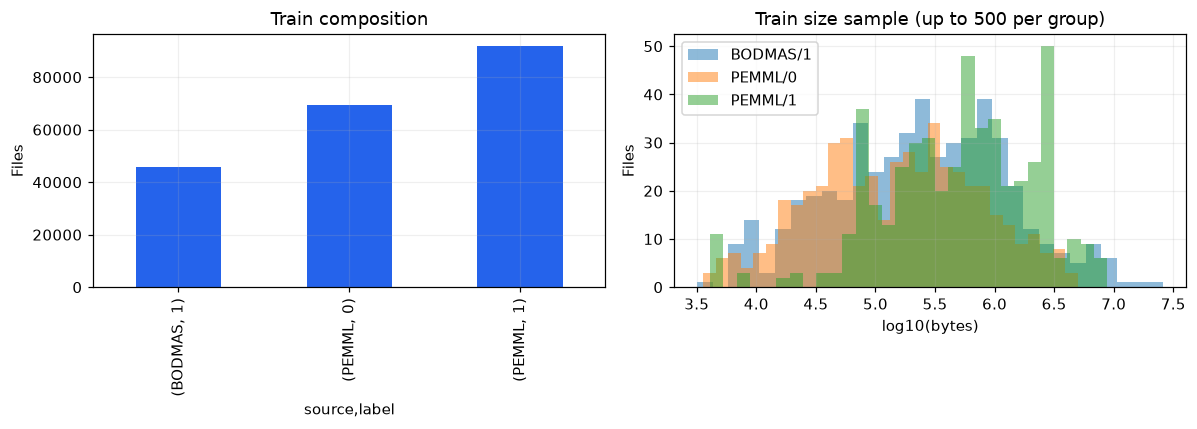

In [88]:
train_manifest = manifest[manifest.split.eq("train")]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
train_manifest.groupby(["source", "label"]).size().plot.bar(ax=axes[0], color="#2563eb")
axes[0].set(title="Train composition", ylabel="Files")
# stat의 file size는 출처 CSV의 length가 아니라 현재 실제 파일 크기입니다.
eda_rows = train_manifest.groupby(["source", "label"], group_keys=False).head(500)
size_frame = eda_rows[["source", "label"]].copy()
size_frame["bytes"] = [Path(p).stat().st_size for p in eda_rows.path]
for (source, label), group in size_frame.groupby(["source", "label"]):
    axes[1].hist(np.log10(group.bytes.clip(lower=1)), bins=30, alpha=.5, label=f"{source}/{label}")
axes[1].set(title="Train size sample (up to 500 per group)", xlabel="log10(bytes)", ylabel="Files")
axes[1].legend()
fig.tight_layout()
fig.savefig(REPORT_DIR / "train_composition.png", bbox_inches="tight")
plt.show()


## 7. 파일 3개로 특징 추출 미리 보기


In [89]:
preview = []
for row in train_manifest.groupby(["source", "label"]).head(1).itertuples():
    record = fe.extract_pe_features(
        row.path, source=row.source, reference_sha256=row.sha256,
        machine_override=row.machine if row.source == "BODMAS" else None,
        subsystem_override=row.subsystem if row.source == "BODMAS" else None,
        config=EXTRACTOR_CONFIG,
    )
    preview.append({
        "sample_id": row.sample_id, "source": row.source, "parse_status": record["parse_status"],
        "feature_count": 0 if record["vector"] is None else len(record["vector"]),
        "reference_sha256": row.sha256, "content_sha256": record["content_sha256"],
        "error_reason": record["error_reason"],
    })
display(pd.DataFrame(preview))
# BODMAS의 두 해시가 다른 것은 비실행화된 제공 파일의 특성입니다.
# PEMML처럼 '원본 해시와 반드시 같음'을 강제하지 않습니다.


,sample_id,source,parse_status,feature_count,reference_sha256,content_sha256,error_reason
0,P_233283,PEMML,ok,341,984d732c9f32197232918f2fce0aa9cedc1011d93e32ac...,984d732c9f32197232918f2fce0aa9cedc1011d93e32ac...,None
1,P_498837,PEMML,ok,341,6ee0fa33922cf79ea212a518c757c139877e145a50b42f...,6ee0fa33922cf79ea212a518c757c139877e145a50b42f...,None
2,B_7f2d1e70b3dcb0c8e85a8e7c88ef2594c2f371055ba4...,BODMAS,partial,341,7f2d1e70b3dcb0c8e85a8e7c88ef2594c2f371055ba49e...,84222d1561877afa0e7f39531afa1783bf6e9a4b527930...,None


## 8. PE 특징 캐시 생성/재사용

전체 모드는 약 258,841개 파일을 읽기 때문에 최초 추출에 시간이 걸립니다.
이후 모델/threshold 실험은 캐시를 재사용합니다. 추출 중 중단되면 이 셀을 다시 실행하세요.
청크 완료 시에만 저장하므로 미완료 청크는 다시 계산합니다.
파싱 실패는 전체 목록에서 사라지지 않고 기록으로 유지됩니다.


In [91]:
X, metadata, CACHE_DIR = cache_features(
    manifest, ARTIFACT_ROOT / "feature_cache", EXTRACTOR_CONFIG,
    workers=EXTRACTION_WORKERS, chunk_size=CACHE_CHUNK_SIZE,
)
if X.shape != (len(metadata), len(FEATURE_NAMES)) or np.isinf(X).any():
    raise ValueError("특징 형태/무한값 오류")
valid = metadata.parse_status.isin(["ok", "partial"]).to_numpy()
status_table = metadata.groupby(["split", "source", "label", "parse_status"]).size().rename("count").reset_index()
display(status_table)
status_table.to_csv(REPORT_DIR / "extraction_status.csv", index=False)
metadata.loc[~valid].to_csv(REPORT_DIR / "extraction_errors.csv", index=False)
print("X:", X.shape, X.dtype, "| RAM for matrix:", round(X.nbytes / 1024**2, 1), "MiB")
print("캐시:", CACHE_DIR, "| 예측 가능한 파일:", int(valid.sum()), "/", len(metadata))


특징 캐시: 512/258,841
특징 캐시: 1,024/258,841
특징 캐시: 1,536/258,841
특징 캐시: 2,048/258,841
특징 캐시: 2,560/258,841
특징 캐시: 3,072/258,841
특징 캐시: 3,584/258,841
특징 캐시: 4,096/258,841
특징 캐시: 4,608/258,841
특징 캐시: 5,120/258,841
특징 캐시: 5,632/258,841
특징 캐시: 6,144/258,841
특징 캐시: 6,656/258,841
특징 캐시: 7,168/258,841
특징 캐시: 7,680/258,841
특징 캐시: 8,192/258,841
특징 캐시: 8,704/258,841
특징 캐시: 9,216/258,841
특징 캐시: 9,728/258,841
특징 캐시: 10,240/258,841
특징 캐시: 10,752/258,841
특징 캐시: 11,264/258,841
특징 캐시: 11,776/258,841
특징 캐시: 12,288/258,841
특징 캐시: 12,800/258,841
특징 캐시: 13,312/258,841
특징 캐시: 13,824/258,841
특징 캐시: 14,336/258,841
특징 캐시: 14,848/258,841
특징 캐시: 15,360/258,841
특징 캐시: 15,872/258,841
특징 캐시: 16,384/258,841
특징 캐시: 16,896/258,841
특징 캐시: 17,408/258,841
특징 캐시: 17,920/258,841
특징 캐시: 18,432/258,841
특징 캐시: 18,944/258,841
특징 캐시: 19,456/258,841
특징 캐시: 19,968/258,841
특징 캐시: 20,480/258,841
특징 캐시: 20,992/258,841
특징 캐시: 21,504/258,841
특징 캐시: 22,016/258,841
특징 캐시: 22,528/258,841
특징 캐시: 23,040/258,841
특징 캐시: 23,552/258,841
특징 캐시: 24

,split,source,label,parse_status,count
0,test,BODMAS,1,ok,2537
1,test,BODMAS,1,partial,3192
2,test,PEMML,0,error,1
3,test,PEMML,0,ok,7673
4,test,PEMML,0,partial,1007
5,test,PEMML,1,error,2
6,test,PEMML,1,ok,6880
7,test,PEMML,1,partial,4592
8,train,BODMAS,1,ok,16859
9,train,BODMAS,1,partial,28975


X: (258841, 341) float32 | RAM for matrix: 336.7 MiB
캐시: C:\stage1\artifacts\stage1_xgboost\feature_cache\9d6a52187ee19d77e76b301b | 예측 가능한 파일: 258807 / 258841


## 9. Train 특징 검사와 출처 편향 진단

NaN은 XGBoost가 직접 처리하며, 0은 실제 구조 부재입니다. scaler는 사용하지 않습니다.
출처별 byte histogram을 비교해 BODMAS 제공 방식에 따른 차이가 큰지 확인합니다.
보정은 Machine/Subsystem 두 특징에만 적용했으므로 히스토그램은 제공된 바이트를 반영합니다.


import_symbol_count           0.149210
import_dll_count              0.149210
directory_import_size         0.149210
directory_import_present      0.149210
import_ordinal_count          0.149210
directory_resource_size       0.022082
directory_resource_present    0.022082
directory_reserved_present    0.021343
directory_reserved_size       0.021343
directory_export_size         0.011944
directory_export_present      0.011944
export_forwarder_count        0.011944
export_symbol_count           0.011944
overlay_entropy               0.007414
overlay_present               0.007414
Name: missing_fraction, dtype: float64

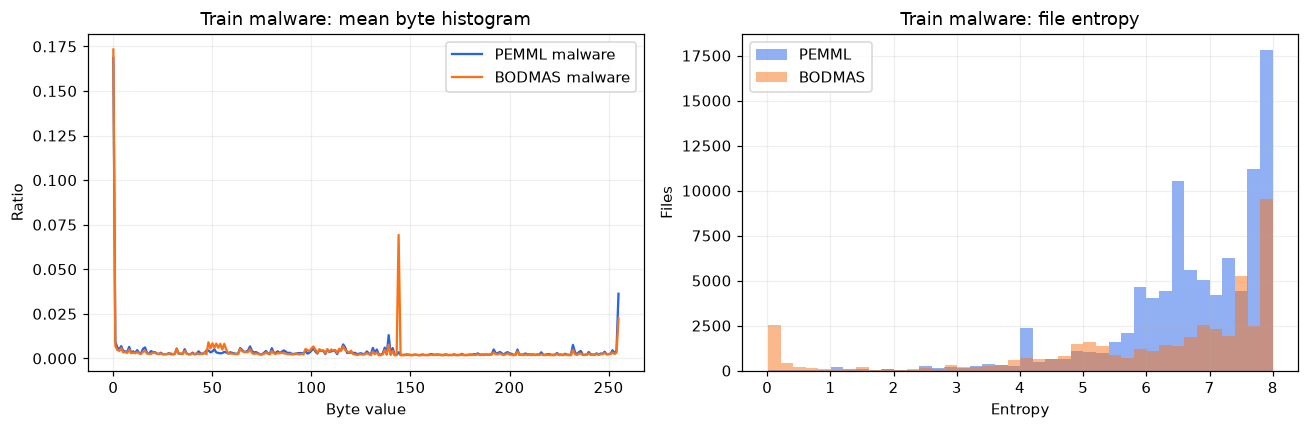

In [92]:
train_valid = metadata.split.eq("train").to_numpy() & valid
train_X = pd.DataFrame(X[train_valid], columns=FEATURE_NAMES)
display(train_X.isna().mean().sort_values(ascending=False).head(15).rename("missing_fraction"))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for source, color in [("PEMML", "#2563eb"), ("BODMAS", "#f97316")]:
    mask = train_valid & metadata.source.eq(source).to_numpy() & metadata.label.eq(1).to_numpy()
    axes[0].plot(range(256), np.nanmean(X[mask][:, -256:], axis=0), label=f"{source} malware", color=color)
    axes[1].hist(X[mask, FEATURE_NAMES.index("file_entropy")], bins=40, alpha=.5, label=source, color=color)
axes[0].set(title="Train malware: mean byte histogram", xlabel="Byte value", ylabel="Ratio")
axes[1].set(title="Train malware: file entropy", xlabel="Entropy", ylabel="Files")
for ax in axes:
    ax.legend()
fig.tight_layout()
fig.savefig(REPORT_DIR / "train_source_features.png", bbox_inches="tight")
plt.show()


## 10. XGBoost 설정과 학습 함수

Model A는 PEMML train만, Model B는 통합 train을 학습합니다.
각각 해당 validation으로 early stopping하며 **test는 사용하지 않습니다**.
binary:logistic은 이진 logloss를 최적화합니다. 적당한 트리 깊이와 낮은 학습률로 시작하고,
early stopping으로 필요한 트리 수를 결정합니다. 아래 값은 조정 가능한 첫 실험 설정입니다.
SMOTE/무조건적인 클래스 가중치 없이 원래 분포의 baseline을 먼저 만듭니다.


In [93]:
MODEL_PARAMS = dict(
    objective="binary:logistic", eval_metric="logloss",
    n_estimators=2000 if RUN_MODE == "full" else 20,
    learning_rate=0.05, max_depth=6, min_child_weight=2,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.0, reg_lambda=1.0, scale_pos_weight=1.0,
    tree_method="hist", device=DEVICE, n_jobs=min(8, os.cpu_count() or 2),
    random_state=SEED, early_stopping_rounds=50 if RUN_MODE == "full" else 3,
)

def feature_frame(mask):
    # 명시적인 whitelist 열만 DataFrame으로 만든다. source/label/hash 열을 join하지 않는다.
    return pd.DataFrame(X[mask], columns=FEATURE_NAMES)

def train_xgb(source_filter=None):
    source_mask = np.ones(len(metadata), dtype=bool) if source_filter is None else metadata.source.eq(source_filter).to_numpy()
    tr = train_valid & source_mask
    va = metadata.split.eq("validation").to_numpy() & valid & source_mask
    if metadata.loc[tr, "label"].nunique() != 2 or metadata.loc[va, "label"].nunique() != 2:
        raise ValueError("학습/검증에 유효한 정상·악성이 모두 필요합니다.")
    model = XGBClassifier(**MODEL_PARAMS)
    model.fit(
        feature_frame(tr), metadata.loc[tr, "label"].to_numpy(),
        eval_set=[(feature_frame(tr), metadata.loc[tr, "label"].to_numpy()),
                  (feature_frame(va), metadata.loc[va, "label"].to_numpy())],
        verbose=100 if RUN_MODE == "full" else False,
    )
    return model


### 10-1. Model A — PEMML-only 기준 모델


In [94]:
model_pemml = train_xgb("PEMML")
model_pemml.save_model(RUN_DIR / "pemml_checkpoint.json")
print("PEMML-only best iteration:", model_pemml.best_iteration)


c:\stage1\venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:58:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:55: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
c:\stage1\venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:58:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-logloss:0.64321	validation_1-logloss:0.64336
[100]	validation_0-logloss:0.05171	validation_1-logloss:0.05985
[200]	validation_0-logloss:0.02908	validation_1-logloss:0.03935
[300]	validation_0-logloss:0.01929	validation_1-logloss:0.03205
[400]	validation_0-logloss:0.01315	validation_1-logloss:0.02812
[500]	validation_0-logloss:0.00924	validation_1-logloss:0.02581
[600]	validation_0-logloss:0.00674	validation_1-logloss:0.02445
[700]	validation_0-logloss:0.00494	validation_1-logloss:0.02348
[800]	validation_0-logloss:0.00375	validation_1-logloss:0.02301
[900]	validation_0-logloss:0.00288	validation_1-logloss:0.02272
[1000]	validation_0-logloss:0.00229	validation_1-logloss:0.02259
[1036]	validation_0-logloss:0.00211	validation_1-logloss:0.02263
PEMML-only best iteration: 986


### 10-2. Model B — PEMML + BODMAS 통합 모델


In [95]:
model_combined = train_xgb()
model_combined.save_model(RUN_DIR / "combined_checkpoint.json")
print("Combined best iteration:", model_combined.best_iteration)


c:\stage1\venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [14:04:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:55: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
c:\stage1\venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [14:04:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-logloss:0.59696	validation_1-logloss:0.59711
[100]	validation_0-logloss:0.04257	validation_1-logloss:0.05046
[200]	validation_0-logloss:0.02361	validation_1-logloss:0.03351
[300]	validation_0-logloss:0.01555	validation_1-logloss:0.02748
[400]	validation_0-logloss:0.01072	validation_1-logloss:0.02445
[500]	validation_0-logloss:0.00754	validation_1-logloss:0.02248
[600]	validation_0-logloss:0.00540	validation_1-logloss:0.02128
[700]	validation_0-logloss:0.00391	validation_1-logloss:0.02041
[800]	validation_0-logloss:0.00294	validation_1-logloss:0.01999
[900]	validation_0-logloss:0.00229	validation_1-logloss:0.01985
[989]	validation_0-logloss:0.00184	validation_1-logloss:0.01977
Combined best iteration: 939


## 11. 학습 곡선과 특징 중요도


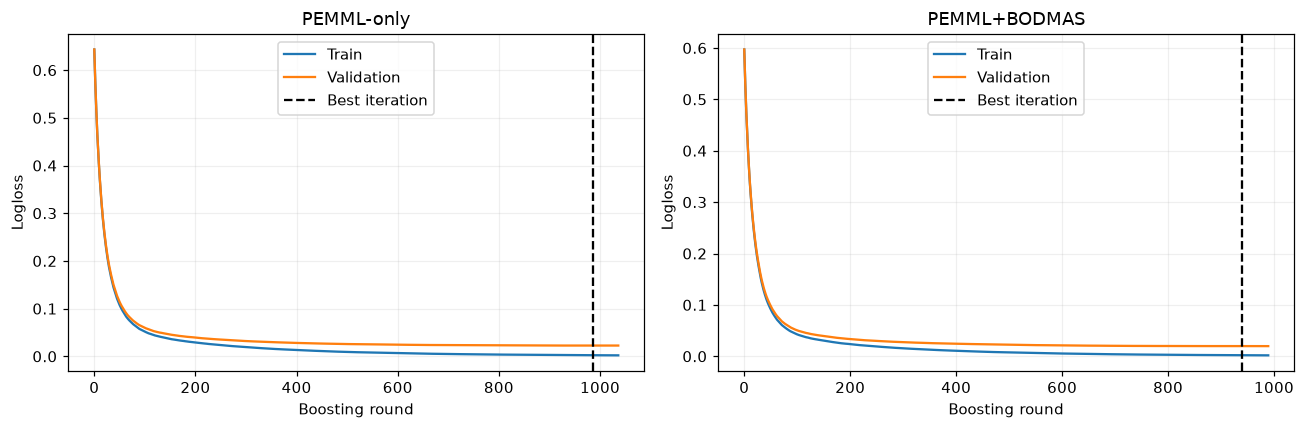

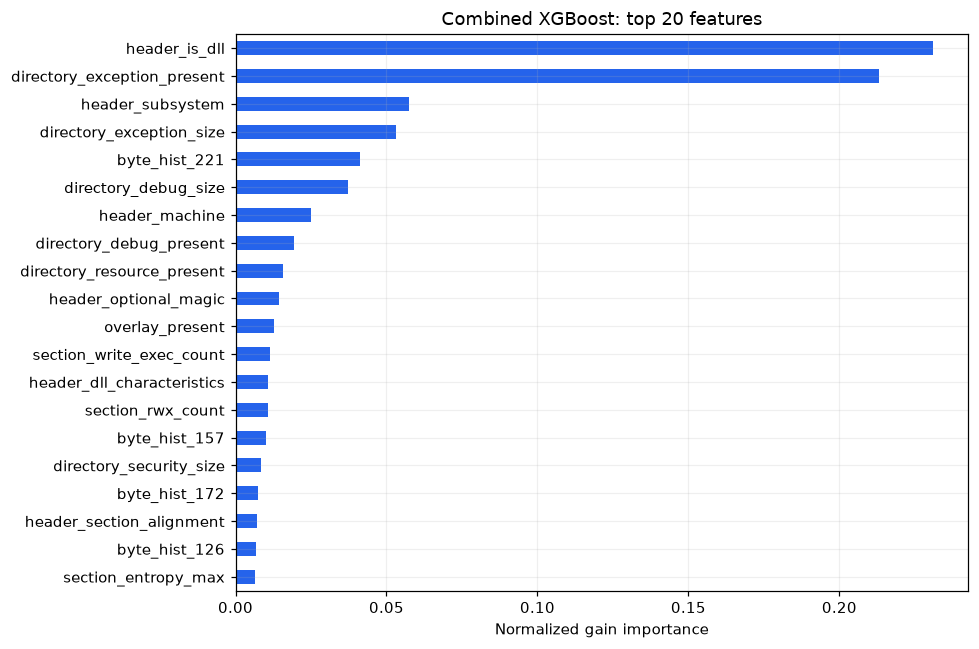

In [96]:
models = {"PEMML-only": model_pemml, "PEMML+BODMAS": model_combined}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
histories = {}
for ax, (name, model) in zip(axes, models.items()):
    history = model.evals_result()
    histories[name] = history
    ax.plot(history["validation_0"]["logloss"], label="Train")
    ax.plot(history["validation_1"]["logloss"], label="Validation")
    ax.axvline(model.best_iteration, linestyle="--", color="black", label="Best iteration")
    ax.set(title=name, xlabel="Boosting round", ylabel="Logloss")
    ax.legend()
fig.tight_layout()
fig.savefig(REPORT_DIR / "learning_curves.png", bbox_inches="tight")
json_write(REPORT_DIR / "learning_history.json", histories)
plt.show()

# 중요도는 인과 설명이 아닙니다. 파일 크기 등 출처 단서가 지배하는지 점검하는 용도입니다.
importance = pd.Series(model_combined.feature_importances_, index=FEATURE_NAMES, name="gain_importance").sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
importance.tail(20).plot.barh(ax=ax, color="#2563eb")
ax.set(title="Combined XGBoost: top 20 features", xlabel="Normalized gain importance")
fig.tight_layout()
fig.savefig(REPORT_DIR / "feature_importance.png", bbox_inches="tight")
importance.to_csv(REPORT_DIR / "feature_importance.csv")
plt.show()


## 12. Validation 점수 계산 — 이 셀은 모델별 한 번이면 됩니다

점수는 보정되지 않은 XGBoost 출력입니다. 0.9를 운영 환경에서 실제 악성 확률 90%라고 단정하지 않습니다.
임계값을 바꾸는 동안 이 점수를 재사용하므로 PE 재파싱/모델 재학습이 필요 없습니다.


In [97]:
def predict_split(model, split):
    mask = metadata.split.eq(split).to_numpy()
    rows = metadata.loc[mask].reset_index(drop=True)
    values = np.full(mask.sum(), np.nan, dtype=float)
    usable = valid[mask]
    if usable.any():
        values[usable] = model.predict_proba(pd.DataFrame(X[mask][usable], columns=FEATURE_NAMES))[:, 1]
    return rows, values

def model_fingerprint(model):
    # 임시 파일 없이 트리와 best_iteration 속성을 함께 지문으로 만든다.
    return hashlib.sha256(model.get_booster().save_raw(raw_format="json")).hexdigest()

val_meta, val_scores = predict_split(model_combined, "validation")
_, val_scores_pemml = predict_split(model_pemml, "validation")
VALIDATION_MODEL_HASHES = {"combined": model_fingerprint(model_combined),
                           "pemml": model_fingerprint(model_pemml)}
val_score_frame = val_meta.assign(combined_score=val_scores, pemml_only_score=val_scores_pemml)
val_score_frame.to_csv(REPORT_DIR / "validation_scores.csv", index=False)
grid = np.linspace(0, 1, 1001)
val_curve = threshold_curve(val_meta, val_scores, grid, error_forward=ERROR_FORWARD)
val_curve.to_csv(REPORT_DIR / "validation_threshold_curve.csv", index=False)
recommendation = recommend_thresholds(
    val_meta, val_scores, error_forward=ERROR_FORWARD,
    target_screening_recall=TARGET_SCREENING_RECALL,
    target_malware_precision=TARGET_MALWARE_PRECISION, thresholds=grid,
)
display(pd.Series(recommendation, name="validation proposal"))
json_write(REPORT_DIR / "threshold_recommendation.json", recommendation)
# feasible=False이면 목표를 달성했다고 간주하지 않습니다.
# 추천은 자동 적용하지 않습니다. 아래 LOW/HIGH 셀에서 그래프/수치를 보고 선택합니다.


feasible                                                                        True
low                                                                             0.82
high                                                                           0.821
reason                             validation 그리드의 경험적 목표를 만족하는 제안입니다. 설정에 수동 적용하세요.
selection_split                                                           validation
target_screening_recall                                                         0.99
target_malware_precision                                                        0.99
error_forward                                                                  False
candidate_count                                                                 1001
validation_screening_recall                                                 0.990002
validation_benign_forward_rate                                              0.004723
validation_overall_forward_rate                                  

## 13. 임계값 실험 — 이 셀과 다음 셀만 반복 실행합니다

LOW를 낮추면 악성 누락이 줄어드는 대신 정상도 2차로 많이 갑니다.
HIGH는 Suspicious와 Malware의 표시를 나누며, LOW가 같다면 2차 전달량에는 영향을 주지 않습니다.
목표 recall/precision 0.99는 제안용 설정값이며 보장된 성능이 아닙니다.


,n_total,n_errors,score_coverage,screening_recall,screening_fnr,benign_forward_rate,overall_forward_rate,malware_precision,average_precision_scored,roc_auc_scored
source,,,,,,,,,,
overall,25884,2,0.999923,0.997617,0.002383,0.02062,0.669951,0.997945,0.999811,0.999635
PEMML,20155,2,0.999901,0.997473,0.002527,0.02062,0.576730,0.996907,0.999645,0.999546
BODMAS,5729,0,1.000000,0.997905,0.002095,NaN,0.997905,NaN,NaN,NaN


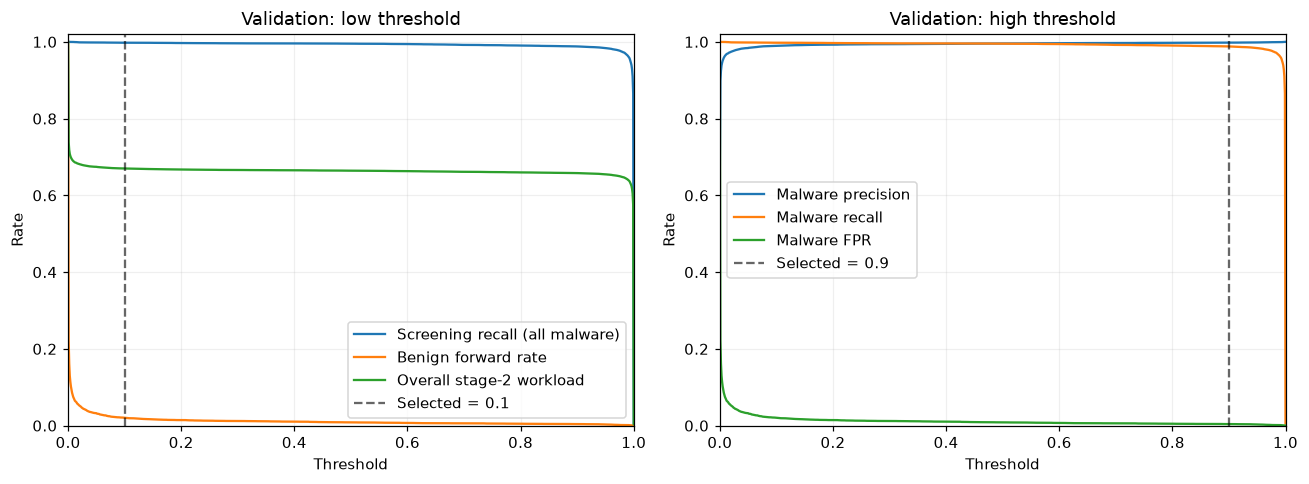

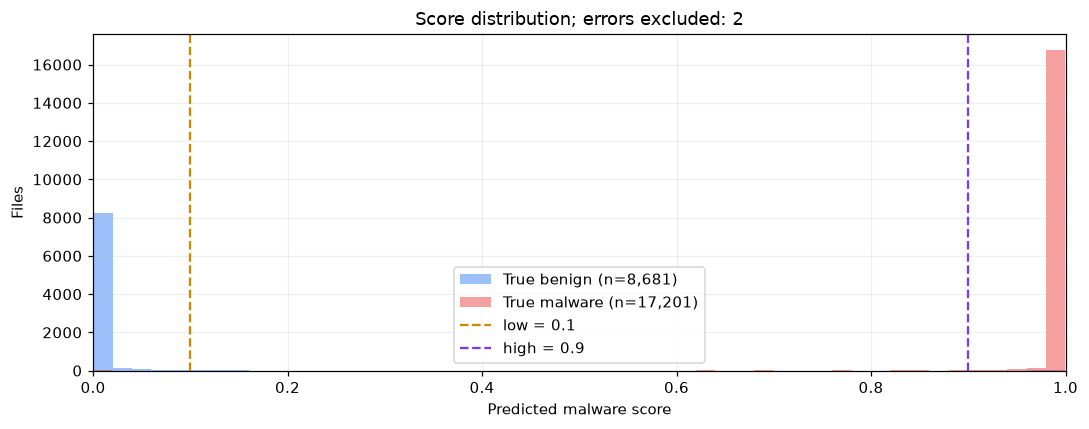

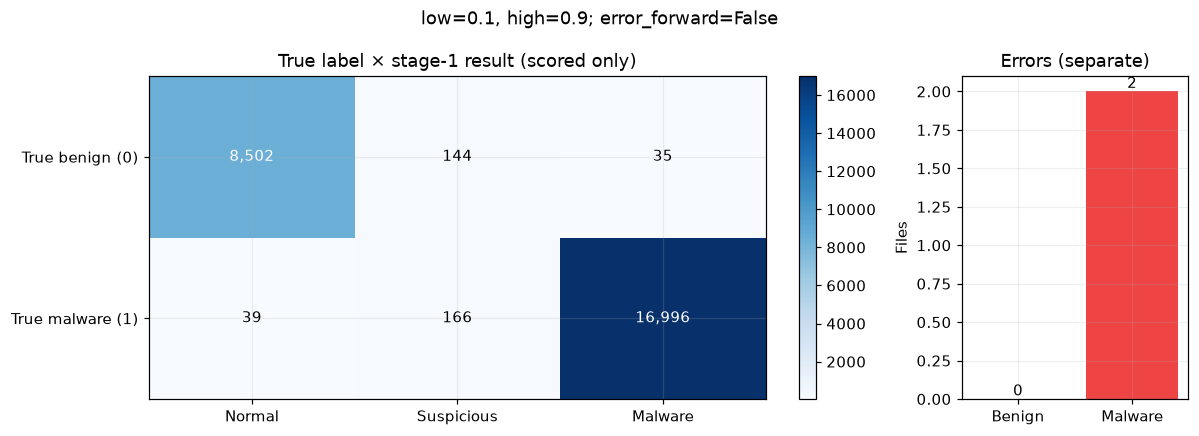

In [98]:
LOW = 0.10
HIGH = 0.90
# 추천을 채택하고 싶다면 feasible을 확인한 뒤 직접 아래를 실행합니다.
# assert recommendation["feasible"], recommendation["reason"]
# LOW, HIGH = recommendation["low"], recommendation["high"]

def inspect_thresholds(low, high, save=False):
    table = evaluate_scores(val_meta, val_scores, low, high, error_forward=ERROR_FORWARD)
    columns = ["n_total", "n_errors", "score_coverage", "screening_recall", "screening_fnr",
               "benign_forward_rate", "overall_forward_rate", "malware_precision",
               "average_precision_scored", "roc_auc_scored"]
    display(table[columns])
    figures = {
        "validation_thresholds": plot_threshold_tradeoffs(val_curve, low=low, high=high),
        "validation_score_histogram": plot_score_histogram(val_meta, val_scores, low, high),
        "validation_three_way": plot_three_way_confusion(val_meta, val_scores, low, high, error_forward=ERROR_FORWARD),
    }
    for name, fig in figures.items():
        if save:
            fig.savefig(REPORT_DIR / (name + ".png"), bbox_inches="tight")
        plt.show()
        plt.close(fig)
    return table

validation_metrics = inspect_thresholds(LOW, HIGH, save=True)
validation_metrics.to_csv(REPORT_DIR / "validation_metrics.csv")


### 선택: 버튼으로 적용하는 LOW/HIGH 슬라이더


In [99]:
# ipywidgets가 없으면 위의 숫자 설정 셀만 사용해도 모든 실험이 가능합니다.
# 슬라이더는 미리 보기만 수행합니다. 최종 값은 LOW/HIGH 변수에 직접 반영하세요.
try:
    import ipywidgets as widgets
    control = widgets.interactive(
        lambda low, high: inspect_thresholds(low, high) if low < high else print("LOW < HIGH가 필요합니다."),
        {"manual": True, "manual_name": "Validation 비교"},
        low=widgets.FloatSlider(value=LOW, min=0, max=0.999, step=0.001),
        high=widgets.FloatSlider(value=HIGH, min=0.001, max=1, step=0.001),
    )
    display(control)
except ImportError:
    print("ipywidgets 미설치: 위의 LOW/HIGH 숫자를 바꿔 실험하세요.")


interactive(children=(FloatSlider(value=0.1, description='low', max=0.999, step=0.001), FloatSlider(value=0.9,…

## 14. Validation 최종 확정

Test를 보기 전에 두 임계값과 모델을 확정합니다.
두 모델은 우선 동일 LOW/HIGH로 비교해 정책 차이와 데이터 추가 효과를 섞지 않습니다.
Test 결과를 보고 값을 다시 조절하면 그 Test는 더 이상 최종 독립 평가가 아닙니다.


In [100]:
route_scores([], LOW, HIGH, error_forward=ERROR_FORWARD)  # 경계 유효성 검사
def current_policy():
    return {"low": float(LOW), "high": float(HIGH), "error_forward": False,
            "combined_booster_sha256": model_fingerprint(model_combined),
            "pemml_booster_sha256": model_fingerprint(model_pemml)}

candidate_policy = current_policy()
if (candidate_policy["combined_booster_sha256"] != VALIDATION_MODEL_HASHES["combined"] or
        candidate_policy["pemml_booster_sha256"] != VALIDATION_MODEL_HASHES["pemml"]):
    raise RuntimeError("Validation 점수 계산 이후 모델이 변경됐습니다. Validation부터 다시 평가하세요.")
lock_path = REPORT_DIR / "test_evaluation_lock.json"
if lock_path.exists() and json.loads(lock_path.read_text()) != candidate_policy:
    raise RuntimeError("이미 본 Test에 새 임계값/모델을 맞추지 마세요. 최종 평가 계획을 다시 정해야 합니다.")
# 잠금 검사를 통과하기 전에는 기존 확정 모델/정책을 덮어쓰지 않는다.
FROZEN_POLICY = candidate_policy
model_combined.save_model(RUN_DIR / "frozen_combined.json")
model_pemml.save_model(RUN_DIR / "frozen_pemml.json")

def assert_frozen_policy():
    if current_policy() != FROZEN_POLICY:
        raise RuntimeError("최종 확정 이후 모델/임계값이 변경됐습니다. 확정 정책과 다른 결과를 저장할 수 없습니다.")
    if lock_path.exists() and json.loads(lock_path.read_text()) != FROZEN_POLICY:
        raise RuntimeError("기존 Test 평가 정책과 다릅니다.")

json_write(REPORT_DIR / "selected_thresholds.json", FROZEN_POLICY)
validation_metrics = evaluate_scores(val_meta, val_scores, LOW, HIGH, error_forward=False)
display(validation_metrics)


,n_total,n_benign,n_malware,n_scored,n_errors,n_error_benign,n_error_malware,score_coverage,score_coverage_benign,score_coverage_malware,...,malware_precision,malware_recall,malware_recall_scored,malware_fpr,malware_fpr_scored,binary_f1_scored_at_low,binary_f1_scored_at_high,average_precision_scored,roc_auc_scored,log_loss_scored
source,,,,,,,,,,,,,,,,,,,,,
overall,25884,8681,17203,25882,2,0,2,0.999923,1.0,0.999884,...,0.997945,0.987967,0.988082,0.004032,0.004032,0.993689,0.992989,0.999811,0.999635,0.019725
PEMML,20155,8681,11474,20153,2,0,2,0.999901,1.0,0.999826,...,0.996907,0.983267,0.983438,0.004032,0.004032,0.991081,0.990127,0.999645,0.999546,0.022751
BODMAS,5729,0,5729,5729,0,0,0,1.000000,NaN,1.000000,...,NaN,0.997382,0.997382,NaN,NaN,NaN,NaN,NaN,NaN,0.009079


## 15. Test 최종 평가 — 전체 / PEMML / BODMAS를 분리해 봅니다


In [101]:
assert_frozen_policy()
json_write(lock_path, FROZEN_POLICY)
test_meta, test_scores = predict_split(model_combined, "test")
_, test_scores_pemml = predict_split(model_pemml, "test")
test_metrics = evaluate_scores(test_meta, test_scores, LOW, HIGH, error_forward=False)
baseline_metrics = evaluate_scores(test_meta, test_scores_pemml, LOW, HIGH, error_forward=False)
display(test_metrics)
comparison = pd.concat({"PEMML-only": baseline_metrics, "PEMML+BODMAS": test_metrics}, names=["model", "source"])
display(comparison[["screening_recall", "screening_fnr", "benign_forward_rate",
                    "overall_forward_rate", "average_precision_scored", "roc_auc_scored"]])
comparison.to_csv(REPORT_DIR / "test_model_comparison.csv")
test_metrics.to_csv(REPORT_DIR / "test_metrics.csv")
test_meta.assign(combined_score=test_scores, pemml_only_score=test_scores_pemml).to_csv(
    REPORT_DIR / "test_scores.csv", index=False)
# BODMAS 단독 행의 FPR/AP/ROC-AUC=NaN은 정상입니다. 정상 표본이 없기 때문입니다.


,n_total,n_benign,n_malware,n_scored,n_errors,n_error_benign,n_error_malware,score_coverage,score_coverage_benign,score_coverage_malware,...,malware_precision,malware_recall,malware_recall_scored,malware_fpr,malware_fpr_scored,binary_f1_scored_at_low,binary_f1_scored_at_high,average_precision_scored,roc_auc_scored,log_loss_scored
source,,,,,,,,,,,,,,,,,,,,,
overall,25884,8681,17203,25881,3,1,2,0.999884,0.999885,0.999884,...,0.998300,0.989885,0.990001,0.003341,0.003341,0.994154,0.994133,0.999841,0.999695,0.016257
PEMML,20155,8681,11474,20152,3,1,2,0.999851,0.999885,0.999826,...,0.997446,0.986927,0.987099,0.003341,0.003341,0.991341,0.992245,0.999677,0.999589,0.020156
BODMAS,5729,0,5729,5729,0,0,0,1.000000,NaN,1.000000,...,NaN,0.995811,0.995811,NaN,NaN,NaN,NaN,NaN,NaN,0.002543


screening_recall  screening_fnr  benign_forward_rate  \
model        source                                                          
PEMML-only   overall          0.998314       0.001686             0.019468   
             PEMML            0.997647       0.002353             0.019468   
             BODMAS           0.999651       0.000349                  NaN   
PEMML+BODMAS overall          0.998431       0.001569             0.020389   
             PEMML            0.997821       0.002179             0.020389   
             BODMAS           0.999651       0.000349                  NaN   

                      overall_forward_rate  average_precision_scored  \
model        source                                                    
PEMML-only   overall              0.670028                  0.999818   
             PEMML                0.576333                  0.999680   
             BODMAS               0.999651                       NaN   
PEMML+BODMAS overall              0.670414                  0.999841   
             PEMML                0.576830                  0.999677   
             BODMAS               0.999651                       NaN   

                      roc_auc_scored  
model        source                   
PEMML-only   overall        0.999652  
             PEMML          0.999586  
             BODMAS              NaN  
PEMML+BODMAS overall        0.999695  
             PEMML          0.999589  
             BODMAS              NaN

## 16. Test 그래프와 운영 비용 비교


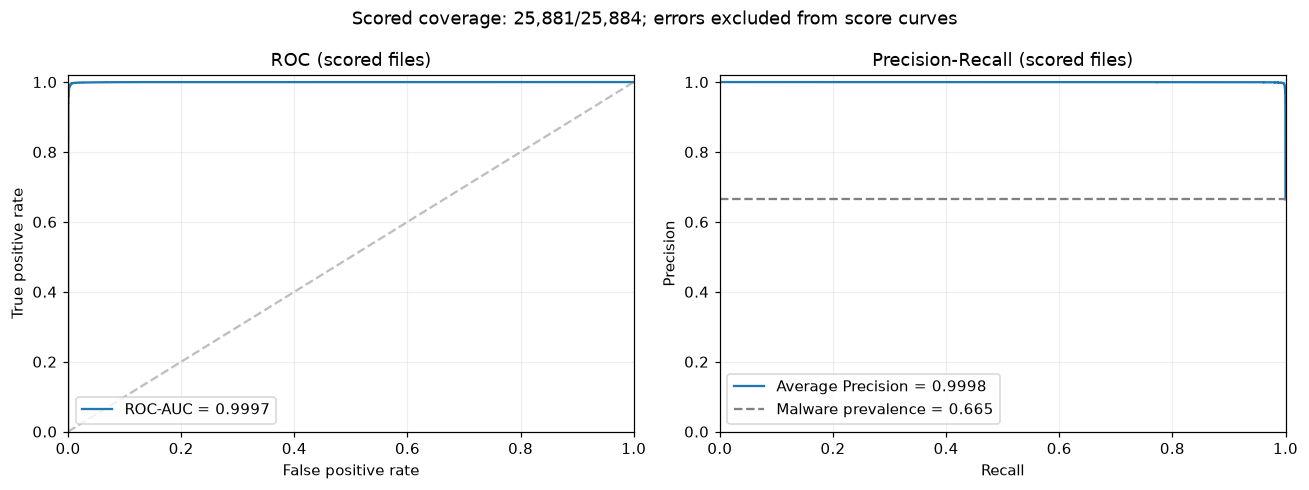

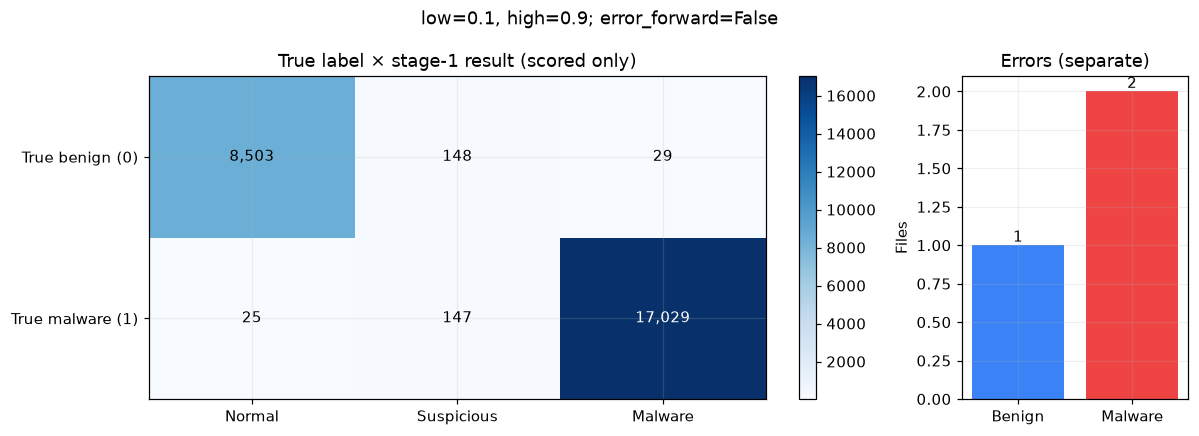

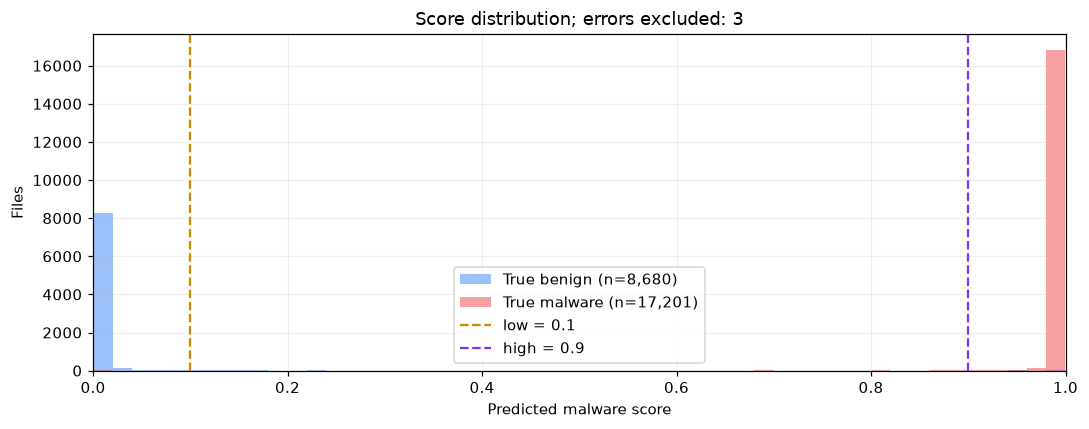

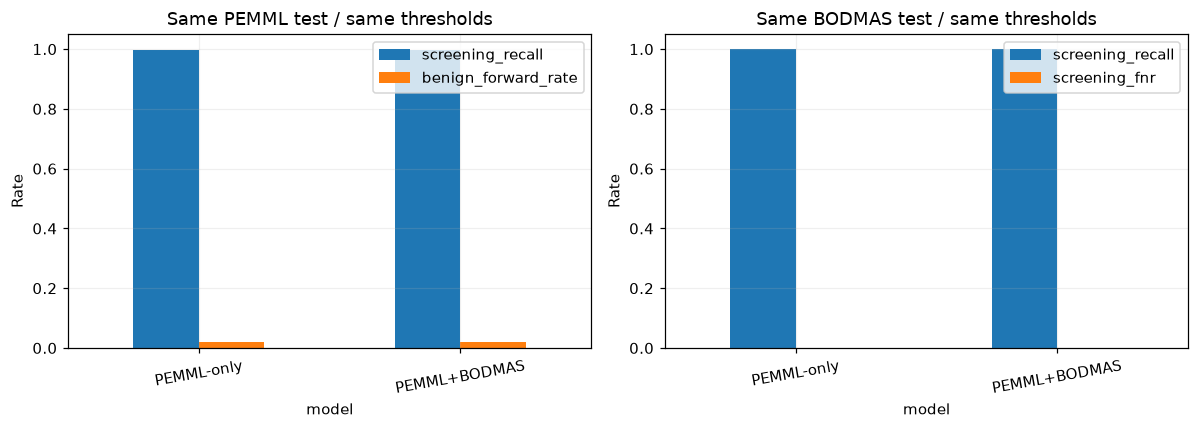

In [102]:
assert_frozen_policy()
for name, fig in {
    "test_roc_pr": plot_score_curves(test_meta, test_scores),
    "test_three_way": plot_three_way_confusion(test_meta, test_scores, LOW, HIGH, error_forward=False),
    "test_score_histogram": plot_score_histogram(test_meta, test_scores, LOW, HIGH),
}.items():
    fig.savefig(REPORT_DIR / (name + ".png"), bbox_inches="tight")
    plt.show()
    plt.close(fig)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, source in zip(axes, ["PEMML", "BODMAS"]):
    part = comparison.xs(source, level="source")
    columns = ["screening_recall", "screening_fnr"] if source == "BODMAS" else ["screening_recall", "benign_forward_rate"]
    part[columns].plot.bar(ax=ax)
    ax.set(title=f"Same {source} test / same thresholds", ylim=(0, 1.05), ylabel="Rate")
    ax.tick_params(axis="x", rotation=10)
fig.tight_layout()
fig.savefig(REPORT_DIR / "baseline_comparison.png", bbox_inches="tight")
plt.show()


## 17. 2차 전달 목록 — 여기서 1차 처리 흐름이 끝납니다

Normal과 Error는 제외합니다. Suspicious·Malware만 입력 ID, 경로, 실제 해시,
1차 점수/판정으로 전달합니다. 이 목록에 정답 label/family를 넣으면 운영 입력과 달라지므로 제외합니다.
아래 코드는 테스트셋 결과를 저장하는 예시이며 2차 모델을 호출하지 않습니다.


In [103]:
assert_frozen_policy()
routing = route_scores(test_scores, LOW, HIGH, error_forward=False)
result_frame = test_meta[["sample_id", "path", "content_sha256", "parse_status", "error_reason"]].copy()
result_frame = pd.concat([result_frame.reset_index(drop=True), routing], axis=1)
result_frame.to_csv(REPORT_DIR / "stage1_results.csv", index=False)
stage2_pending = result_frame.loc[result_frame.needs_stage2,
    ["sample_id", "path", "content_sha256", "malware_score", "stage1_result"]].rename(
    columns={"sample_id": "input_id", "malware_score": "stage1_score"})
stage2_pending.insert(0, "handoff_version", "1.0")
stage2_pending.to_csv(REPORT_DIR / "stage2_pending.csv", index=False)
error_list = result_frame[result_frame.stage1_result.eq("Error")]
error_list.to_csv(REPORT_DIR / "stage1_errors.csv", index=False)
assert not stage2_pending.stage1_result.isin(["Normal", "Error"]).any()
display(result_frame.head(10))
print("2차 전달 후보:", len(stage2_pending), "| 별도 오류:", len(error_list))

# ================== 향후 2차 코드 병합 지점 ==================
# for item in stage2_pending.itertuples(index=False):
#     stage2_preprocess_and_predict(item.path)  # 별도로 작성할 2차 함수에 연결
# stage1_score를 2차 학습 특징으로 자동 추가하지 않습니다.
# 2차 family 클래스/입력 길이/padding 등은 2차 팀이 자기 설정에 저장합니다.
# ============================================================


,sample_id,path,content_sha256,parse_status,error_reason,malware_score,stage1_result,needs_stage2,score_valid
0,P_233285,D:\Dataset\training_dataset\test\benign\P_233285,984ee03e9735f653256cf826f7ee5b7b8d6d9b49dfb9b8...,ok,,0.000015,Normal,False,True
1,P_233319,D:\Dataset\training_dataset\test\benign\P_233319,9876d159409267bc00da3f8cb7257c0af49bdb0ae7237c...,ok,,0.000005,Normal,False,True
2,P_233326,D:\Dataset\training_dataset\test\benign\P_233326,988d03dc5dded213d90740851dbaa1933ad26acb569568...,partial,,0.018092,Normal,False,True
3,P_233577,D:\Dataset\training_dataset\test\benign\P_233577,99247397752f14a05274faa9e91f7a995094d91246e38e...,ok,,0.000017,Normal,False,True
4,P_233331,D:\Dataset\training_dataset\test\benign\P_233331,98812f2953f15d0b680258f49641b559f0633863448724...,ok,,0.002394,Normal,False,True
5,P_233340,D:\Dataset\training_dataset\test\benign\P_233340,9884c0afba54677f65a70fce707b0f85d986ad6d016892...,ok,,0.000058,Normal,False,True
6,P_233367,D:\Dataset\training_dataset\test\benign\P_233367,98a98bf09cfc6f071631f072cdca69a744a252753b90e3...,ok,,0.000011,Normal,False,True
7,P_233623,D:\Dataset\training_dataset\test\benign\P_233623,9950e603f36c91815f7ec40e78c5b808f2e34cd6990644...,ok,,0.000003,Normal,False,True
8,P_233630,D:\Dataset\training_dataset\test\benign\P_233630,993982a0a2e52b656a8f5ccc53839f3ec8903042415501...,ok,,0.039173,Normal,False,True
9,P_233661,D:\Dataset\training_dataset\test\benign\P_233661,997c0e69c490770815dd64189ad2f59f8309ad266981bf...,ok,,0.000222,Normal,False,True


2차 전달 후보: 17353 | 별도 오류: 3


## 18. 프로그램 배포용 패키지 저장

통합 모델과 PEMML-only 모델을 모두 별도 저장합니다. 이번 실행은 통합 모델을 1차 프로그램 대상으로
사용하며 테스트 수치로 모델을 자동 교체하지 않습니다.
실제 성능 검토 후 모델 선택을 바꾸려면 별도의 validation 선택 계획을 사용하세요.
smoke 모드 패키지는 기능 검사 전용이며 실사용 모델이 아닙니다.


In [104]:
assert_frozen_policy()
training_config = {
    "run_id": RUN_ID, "run_mode": RUN_MODE, "params": MODEL_PARAMS,
    "seed": SEED, "threshold_policy": FROZEN_POLICY,
    "feature_cache": str(CACHE_DIR), "score_calibrated": False,
}
# 단일 클래스 지표의 NaN을 JSON null로 변환해 올바른 JSON으로 저장합니다.
validation_json = json.loads(validation_metrics.to_json(orient="index"))
BUNDLE_DIR = save_bundle(
    RUN_DIR / "combined_bundle", model_combined, low=LOW, high=HIGH,
    extractor_config=EXTRACTOR_CONFIG, data_audit=dataset_audit,
    training_config=training_config, validation_summary=validation_json,
)
baseline_val_metrics = evaluate_scores(val_meta, val_scores_pemml, LOW, HIGH, error_forward=False)
BASELINE_BUNDLE_DIR = save_bundle(
    RUN_DIR / "pemml_only_bundle", model_pemml, low=LOW, high=HIGH,
    extractor_config=EXTRACTOR_CONFIG, data_audit=dataset_audit,
    training_config={**training_config, "training_source": "PEMML only"},
    validation_summary=json.loads(baseline_val_metrics.to_json(orient="index")),
)
print("프로그램용 통합 패키지:", BUNDLE_DIR)
display(pd.Series(sorted(p.name for p in BUNDLE_DIR.iterdir()), name="saved assets"))


프로그램용 통합 패키지: C:\stage1\artifacts\stage1_xgboost\runs\20260916T032236_860661Z_full\combined_bundle


0           INTEGRATION.md
1     bundle_manifest.json
2       dataset_audit.json
3         environment.json
4      feature_config.json
5       feature_names.json
6       label_mapping.json
7        model_config.json
8       preprocessing.json
9         requirements.txt
10                  stage1
11    stage2_contract.json
12          xgb_model.json
13      xgb_threshold.json
Name: saved assets, dtype: str

## 19. 저장 → 로드 결과 일치 검사


In [105]:
detector = Stage1Detector(BUNDLE_DIR)
probe_mask = metadata.split.eq("validation").to_numpy() & valid
probe_frame = feature_frame(probe_mask).head(64)
before = model_combined.predict_proba(probe_frame)[:, 1]
after = detector.model.predict_proba(probe_frame)[:, 1]
np.testing.assert_allclose(before, after, rtol=1e-6, atol=1e-7)

# 실제 PE를 한 번 재추출해서도 학습 캐시와 같은 점수가 나오는지 확인합니다.
probe = metadata.loc[probe_mask].iloc[0]
loaded_result = detector.analyze_file(
    probe.path, input_id=probe.sample_id, source=probe.source,
    reference_sha256=probe.sha256,
    machine_override=probe.machine if probe.source == "BODMAS" else None,
    subsystem_override=probe.subsystem if probe.source == "BODMAS" else None,
)
np.testing.assert_allclose(before[0], loaded_result["malware_score"], rtol=1e-6, atol=1e-7)
print("64개 이내 특징 점수 및 실제 파일 재추출 점수 일치 확인")
display(loaded_result)


64개 이내 특징 점수 및 실제 파일 재추출 점수 일치 확인


{'input_id': 'P_233288',
 'path': 'D:\\Dataset\\training_dataset\\validation\\benign\\P_233288',
 'content_sha256': '9864657f7cb0fe6d0ccfa34e75081e5b2ebee9aac6d1d41b0305a68cd2ed7a8e',
 'parse_status': 'ok',
 'error_reason': None,
 'parse_warnings': [],
 'malware_score': 5.8792247727978975e-05,
 'stage1_result': 'Normal',
 'needs_stage2': False,
 'stage2_pending': None}

## 20. 새 프로그램 파일 입력 예시

새 PE에는 데이터셋 source·label·family가 필요 없습니다. 저장한 패키지를 로드한 뒤 파일 경로만 넘깁니다.
별도 프로그램에서는 BUNDLE_DIR를 sys.path에 추가해 저장된 stage1.runtime을 가져옵니다.
여기서는 동일 코드를 이미 로드했으므로 위 detector를 재사용합니다.


In [106]:
INPUT_FILES = []  # 예: [Path(r"C:\analysis\unknown.exe")]
if INPUT_FILES:
    batch = detector.analyze_files(INPUT_FILES)
    display(pd.DataFrame([{k: v for k, v in r.items() if k != "stage2_pending"} for r in batch["results"]]))
    display(pd.DataFrame(batch["stage2_pending"]))
    display(pd.DataFrame(batch["errors"]))
    json_write(REPORT_DIR / "new_file_results.json", batch)
    # 후속 2차 코드 연결:
    # for item in batch["stage2_pending"]:
    #     second_stage_result = second_stage_predict(item["path"])
else:
    print("INPUT_FILES에 분석할 파일 경로를 넣으면 새 파일 추론을 수행합니다.")


INPUT_FILES에 분석할 파일 경로를 넣으면 새 파일 추론을 수행합니다.


## 산출물 안내

- feature_cache: 수치 특징/행 순서/실제 content SHA/오류의 재사용 캐시.
- runs/<실행 ID>/reports: 데이터 검증, 학습 곡선, 특징 중요도, threshold 곡선,
  validation/test 지표·점수·그래프, 3단계 판정, 2차 대기 목록, 오류 목록.
- combined_bundle 및 pemml_only_bundle: 모델·threshold·특징 순서/규칙·전처리 설정·
  동일 Python 추출/추론 코드·패키지 버전·데이터 이력·2차 입력 계약.

전체 데이터 학습 후에만 최종 성능을 보고합니다. 추출 오류가 발생하면 유효 특징 행의 수는
258,841보다 적어질 수 있으며, 원래 평가 분모와 오류 목록은 함께 남습니다.
실행 중간에서 설정/코드를 바꾼 경우 위쪽 설정 셀부터 다시 실행해 새 run을 생성하세요.
